# Predictive model for accident severity using the US Accidents Dataset

## 1. Aims, objectives and plan

### a) Aims and objectives

The aim of this project is to build a predictive model for accident severity using the US Accidents Dataset. By applying Bayesian Logistic Regression and Neural Networks, this project will compare the strengths and weaknesses of each technique in predicting accident severity based on environmental, traffic, and temporal factors.

The specific objectives are:

**Data Exploration and Preparation**: Conduct thorough data cleaning and feature engineering to prepare relevant factors for predictive modeling.

**Model Development**: Implement and train Bayesian Logistic Regression and Neural Network models, optimizing hyperparameters to achieve accurate accident severity predictions.

**Performance Evaluation**: Compare model performances using metrics like accuracy, F1-score, and interpretability, highlighting differences in each approach.

**Model Interpretation**: Examine predictive insights, such as Bayesian Logistic Regression’s uncertainty and Neural Networks’ feature interactions, to understand each model's unique strengths.

**Practical Recommendations**: Provide actionable insights for emergency response and traffic management based on model outputs, prioritizing areas for resource allocation and safety improvements.
This project will ultimately determine the most effective model for accident severity prediction, informing future applications in traffic safety and response planning.

###  b) Plan


This project will begin with data exploration and preprocessing, where we’ll clean the dataset and engineer relevant features. Following this, we’ll implement **Bayesian Logistic Regression and Neural Network models**, optimizing their hyperparameters to enhance prediction accuracy. Each model will be evaluated on training and testing data using accuracy, F1-score, and other relevant metrics. Finally, we’ll conduct a comparative analysis to determine the best-performing model, discussing results from both technical and business perspectives. The project will conclude with reflections and recommendations for potential applications in traffic safety and future work.

---------------------------------------------------------------------------------------------------------------------

In [1]:
# Let us Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

import warnings
warnings.filterwarnings("ignore")

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 

In [2]:
# Then, we load the dataset

# We have taken the dataset from Kaggle source: https://www.kaggle.com/datasets/sobhanmoosavi/us-accidents/
# For more manageable dataset, a sampled version is available which includes 500,000 accidents. 
## We'll be using this dataset
file_path = 'US_Accidents_March23_sampled_500k.csv'
data = pd.read_csv(file_path)

## 2. Understanding the case study

###  Case study analysis

The US Accidents (2016-2023) dataset contains approximately 500,000 records of traffic accidents from 49 states in the USA. 

The primary objective is to predict accident severity, which is categorized into four levels: 

**1 (low severity)**

**2 (moderate severity)**

**3 (high severity)**

**4 (fatal)**

#### 1. Severity Label Distribution


Severity Distribution:
Severity
2    0.796284
3    0.169040
4    0.026128
1    0.008548
Name: proportion, dtype: float64


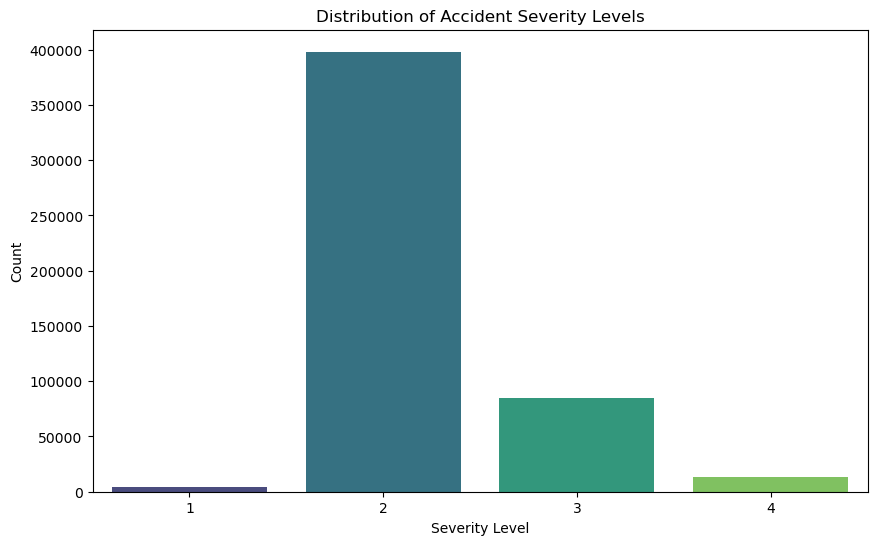

In [3]:
# 1. Severity Label Distribution
severity_counts = data['Severity'].value_counts(normalize=True)
print("\nSeverity Distribution:")
print(severity_counts)

# 1. Plot the distribution of accident severity levels
plt.figure(figsize=(10, 6))
sns.countplot(data=data, x='Severity', palette='viridis')
plt.title('Distribution of Accident Severity Levels')
plt.xlabel('Severity Level')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

**This imbalance suggests a predominance of minor accidents, which can skew model training and affect prediction accuracy.**

The distribution of accident severity is highly imbalanced:
- Severity Level 2: 79.63%
- Severity Level 3: 16.90%
- Severity Level 4: 2.61%
- Severity Level 1: 0.85%

---------------------------------------------------------------------------------------------------------------------

#### 2. Checking for Missing Values

In [4]:
# 2. Checking for Missing Values
missing_values = data.isnull().mean().sort_values(ascending=False) * 100  # Calculate percentage

# Filter out features with missing values
missing_values = missing_values[missing_values > 0]

# Prepare the Markdown table for missing values
markdown_missing_values = missing_values.to_frame(name='Percentage Missing').reset_index()
markdown_missing_values.columns = ['Feature', 'Percentage Missing (%)']  # Renaming columns for clarity
markdown_missing_table = markdown_missing_values.to_markdown(index=False)

# Display the missing values in a Markdown table format
display(Markdown("### Missing Values in Dataset (Percentage):\n" + markdown_missing_table))

### Missing Values in Dataset (Percentage):
| Feature               |   Percentage Missing (%) |
|:----------------------|-------------------------:|
| End_Lat               |                  44.0754 |
| End_Lng               |                  44.0754 |
| Precipitation(in)     |                  28.5232 |
| Wind_Chill(F)         |                  25.8034 |
| Wind_Speed(mph)       |                   7.3974 |
| Visibility(mi)        |                   2.2582 |
| Wind_Direction        |                   2.2394 |
| Humidity(%)           |                   2.226  |
| Weather_Condition     |                   2.2202 |
| Temperature(F)        |                   2.0932 |
| Pressure(in)          |                   1.7856 |
| Weather_Timestamp     |                   1.5348 |
| Nautical_Twilight     |                   0.2966 |
| Civil_Twilight        |                   0.2966 |
| Sunrise_Sunset        |                   0.2966 |
| Astronomical_Twilight |                   0.2966 |
| Airport_Code          |                   0.2892 |
| Street                |                   0.1382 |
| Timezone              |                   0.1014 |
| Zipcode               |                   0.0232 |
| City                  |                   0.0038 |
| Description           |                   0.0002 |

Several features have significant missing data, particularly:

- End_Lat and End_Lng: 44.08%
- Precipitation(in): 28.52%
- Wind_Chill(F): 25.80%3

Features like Visibility, Wind Direction, and Weather Condition also exhibit some missing values (around 2-3%).

**Missing data can hinder model performance and may necessitate imputation or exclusion of certain features.**

---------------------------------------------------------------------------------------------------------------------

#### 3. Outlier Analysis

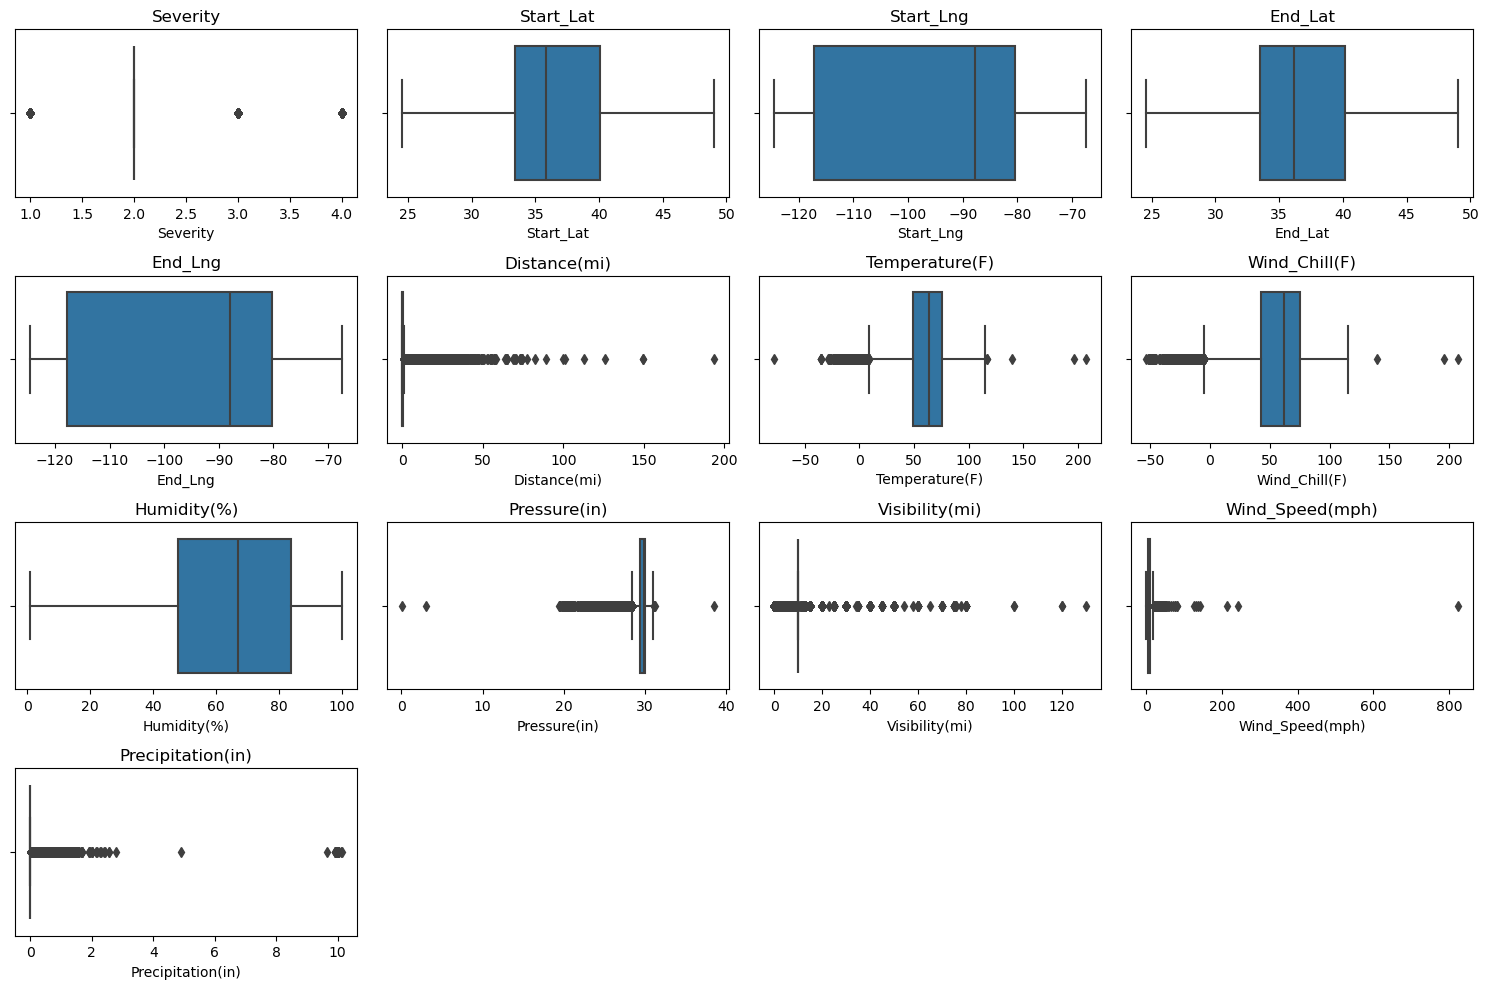

In [5]:
# 3. Outlier Analysis
# Checking for numerical features and visualizing them using boxplots
numerical_features = data.select_dtypes(include=['float64', 'int64']).columns

# Boxplot for key numerical features to detect outliers
plt.figure(figsize=(15, 10))
for i, feature in enumerate(numerical_features):
    plt.subplot(4, 4, i + 1)
    sns.boxplot(x=data[feature])
    plt.title(feature)
plt.tight_layout()
plt.show()

---------------------------------------------------------------------------------------------------------------------

In [6]:
# Summary statistics
summary_statistics = data[numerical_features].describe()

# Prepare the Markdown table for summary statistics
markdown_summary = summary_statistics.to_markdown()

# Display the summary statistics in a Markdown table format
display(Markdown("### Summary Statistics:\n" + markdown_summary))


### Summary Statistics:
|       |      Severity |    Start_Lat |   Start_Lng |      End_Lat |     End_Lng |   Distance(mi) |   Temperature(F) |   Wind_Chill(F) |   Humidity(%) |   Pressure(in) |   Visibility(mi) |   Wind_Speed(mph) |   Precipitation(in) |
|:------|--------------:|-------------:|------------:|-------------:|------------:|---------------:|-----------------:|----------------:|--------------:|---------------:|-----------------:|------------------:|--------------------:|
| count | 500000        | 500000       | 500000      | 279623       | 279623      |  500000        |      489534      |     370983      |   488870      |   491072       |     488709       |      463013       |     357384          |
| mean  |      2.21275  |     36.2064  |    -94.7366 |     36.2732  |    -95.7766 |       0.564317 |          61.6463 |         58.229  |       64.8349 |       29.5366  |          9.09154 |           7.68135 |          0.00828898 |
| std   |      0.486661 |      5.07141 |     17.4058 |      5.26533 |     18.1202 |       1.77487  |          19.0001 |         22.3522 |       22.8262 |        1.00867 |          2.70808 |           5.43136 |          0.101865   |
| min   |      1        |     24.5621  |   -124.497  |     24.5701  |   -124.497  |       0        |         -77.8    |        -53.2    |        1      |        0.12    |          0       |           0       |          0          |
| 25%   |      2        |     33.4168  |   -117.233  |     33.4748  |   -117.778  |       0        |          49      |         43      |       48      |       29.37    |         10       |           4.6     |          0          |
| 50%   |      2        |     35.8321  |    -87.7944 |     36.1927  |    -88.039  |       0.029    |          64      |         62      |       67      |       29.86    |         10       |           7       |          0          |
| 75%   |      2        |     40.0824  |    -80.3596 |     40.1813  |    -80.2524 |       0.465    |          76      |         75      |       84      |       30.03    |         10       |          10.4     |          0          |
| max   |      4        |     48.9996  |    -67.4841 |     48.9989  |    -67.4841 |     193.48     |         207      |        207      |      100      |       38.44    |        130       |         822.8     |         10.13       |

**Summary statistics indicate potential outliers in features such as Wind_Speed (mph), which has a maximum recorded value of 822.8 mph, and Temperature (F) with extreme values reaching 207°F.**

Such extreme values may represent data entry errors or anomalies that require further investigation or filtering.

---------------------------------------------------------------------------------------------------------------------

#### 4. Temporal Patterns

Temporal patterns in accident data may not be evenly distributed across all months and states, which could lead to biased models if certain states or times are underrepresented.

### Addressing Challenges

- Imbalance in Severity Classes:

Techniques such as oversampling the minority classes (e.g., Severity 1 and 4) or employing cost-sensitive learning methods will be necessary to ensure that the model effectively learns from all severity levels.

- Handling Missing Data:

Imputation techniques will be used for features with missing values, especially those that are crucial for predicting severity. Alternatively, features with excessive missing data may be removed to avoid adding noise to the models.

- Outlier Management:

Outliers will be assessed and potentially removed or capped based on domain knowledge, ensuring that they do not adversely impact model training.

## 3. Dataset description 

**Dataset Overview**

- The US Accidents (2016-2023) dataset is a comprehensive collection of traffic accident records covering 49 states in the USA. It data used contains approximately 500,000 records, making it manageable for analysis while retaining sufficient detail for predictive modeling.

- Total Samples: 500,000 accident records
- Features: 46 columns, including:
- ID: Unique identifier for each accident
- Severity: Categorical variable indicating the severity of the accident (1 to 4)
- Start_Time / End_Time: Timestamps for the accident
- Start_Lat / Start_Lng / End_Lat / End_Lng: Geographic coordinates of the accident
- Distance(mi): Distance of the accident in miles
- Weather_Timestamp: Timestamp for weather conditions
- Weather features: Including temperature, humidity, wind speed, and precipitation

**Traffic Attributes**:

ID: This is a unique identifier of the accident record.

Source: Indicates source of the accident report (i.e. the API which reported the accident.).

TMC: A traffic accident may have a Traffic Message Channel (TMC) code which provides more detailed description of the event.

Severity: Shows the severity of the accident, a number between 1 and 4, where 1 indicates the least impact on traffic (i.e., short delay as a result of the accident) and 4 indicates a significant impact on traffic (i.e., long delay).

Start_Time: Shows start time of the accident in local time zone.

End_Time: Shows end time of the accident in local time zone.

Start_Lat: Shows latitude in GPS coordinate of the start point.

Start_Lng: Shows longitude in GPS coordinate of the start point.

End_Lat: Shows latitude in GPS coordinate of the end point.

End_Lng: Shows longitude in GPS coordinate of the end point.

Distance(mi): The length of the road extent affected by the accident.

Description: Shows natural language description of the accident.

**Address Attributes**:

Number: Shows the street number in address field.

Street: Shows the street name in address field.

Side: Shows the relative side of the street (Right/Left) in address field.

City: Shows the city in address field.

County: Shows the county in address field.

State: Shows the state in address field.

Zipcode: Shows the zipcode in address field.

Country: Shows the country in address field.

Timezone: Shows timezone based on the location of the accident (eastern, central, etc.).

**Weather Attributes**:

Airport_Code: Denotes an airport-based weather station which is the closest one to location of the accident.

Weather_Timestamp: Shows the time-stamp of weather observation record (in local time).

Temperature(F): Shows the temperature (in Fahrenheit).

Wind_Chill(F): Shows the wind chill (in Fahrenheit).

Humidity(%): Shows the humidity (in percentage).

Pressure(in): Shows the air pressure (in inches).

Visibility(mi): Shows visibility (in miles).

Wind_Direction: Shows wind direction.

Wind_Speed(mph): Shows wind speed (in miles per hour).

Precipitation(in): Shows precipitation amount in inches, if there is any.

Weather_Condition: Shows the weather condition (rain, snow, thunderstorm, fog, etc.).

**POI Attributes**:

Amenity: A Point-Of-Interest (POI) annotation which indicates presence of amenity in a nearby location.

Bump: A POI annotation which indicates presence of speed bump or hump in a nearby location.

Crossing: A POI annotation which indicates presence of crossing in a nearby location.

Give_Way: A POI annotation which indicates presence of give_way sign in a nearby location.

Junction: A POI annotation which indicates presence of junction in a nearby location.

No_Exit: A POI annotation which indicates presence of no_exit sign in a nearby location.

Railway: A POI annotation which indicates presence of railway in a nearby location.

Roundabout: A POI annotation which indicates presence of roundabout in a nearby location.

Station: A POI annotation which indicates presence of station (bus, train, etc.) in a nearby location.

Stop: A POI annotation which indicates presence of stop sign in a nearby location.

Traffic_Calming: A POI annotation which indicates presence of traffic_calming means in a nearby location.

Traffic_Signal: A POI annotation which indicates presence of traffic_signal in a nearby location.

Turning_Loop: A POI annotation which indicates presence of turning_loop in a nearby location.

**Period-of-Day**:

Sunrise_Sunset: Shows the period of day (i.e. day or night) based on sunrise/sunset.

Civil_Twilight: Shows the period of day (i.e. day or night) based on civil twilight.

Nautical_Twilight: Shows the period of day (i.e. day or night) based on nautical twilight.

Astronomical_Twilight: Shows the period of day (i.e. day or night) based on astronomical twilight.

In [7]:
# Display a sample of the dataset
sample_data = data.sample(5)  # Randomly sample 5 records

# Prepare the Markdown table
markdown_table = sample_data.to_markdown(index=False)

# Display the sample data in a Markdown table format
display(Markdown("#### Sample Data Points:\n" + markdown_table))


#### Sample Data Points:
| ID        | Source   |   Severity | Start_Time                    | End_Time                      |   Start_Lat |   Start_Lng |   End_Lat |   End_Lng |   Distance(mi) | Description                                                                                                                        | Street          | City       | County     | State   | Zipcode    | Country   | Timezone    | Airport_Code   | Weather_Timestamp   |   Temperature(F) |   Wind_Chill(F) |   Humidity(%) |   Pressure(in) |   Visibility(mi) | Wind_Direction   |   Wind_Speed(mph) |   Precipitation(in) | Weather_Condition   | Amenity   | Bump   | Crossing   | Give_Way   | Junction   | No_Exit   | Railway   | Roundabout   | Station   | Stop   | Traffic_Calming   | Traffic_Signal   | Turning_Loop   | Sunrise_Sunset   | Civil_Twilight   | Nautical_Twilight   | Astronomical_Twilight   |
|:----------|:---------|-----------:|:------------------------------|:------------------------------|------------:|------------:|----------:|----------:|---------------:|:-----------------------------------------------------------------------------------------------------------------------------------|:----------------|:-----------|:-----------|:--------|:-----------|:----------|:------------|:---------------|:--------------------|-----------------:|----------------:|--------------:|---------------:|-----------------:|:-----------------|------------------:|--------------------:|:--------------------|:----------|:-------|:-----------|:-----------|:-----------|:----------|:----------|:-------------|:----------|:-------|:------------------|:-----------------|:---------------|:-----------------|:-----------------|:--------------------|:------------------------|
| A-259283  | Source2  |          3 | 2016-07-15 20:15:24           | 2016-07-15 21:45:24           |     39.6319 |    -75.9566 |  nan      |  nan      |          0     | Lane closed due to serious accident on I-95 Northbound at Exits 100 100B-A MD-272 East Rd.                                         | N East Rd       | North East | Cecil      | MD      | 21901      | US        | US/Eastern  | KAPG           | 2016-07-15 19:46:00 |             84.2 |           nan   |            58 |          29.88 |                7 | WSW              |               5.8 |                 nan | Scattered Clouds    | False     | False  | False      | False      | False      | False     | False     | False        | False     | False  | False             | False            | False          | Day              | Day              | Day                 | Day                     |
| A-3069855 | Source2  |          2 | 2018-01-16 12:16:50           | 2018-01-16 13:16:38           |     34.8292 |    -82.3032 |  nan      |  nan      |          0     | Accident on SC-146 Woodruff Rd at I-85.                                                                                            | Woodruff Rd     | Greenville | Greenville | SC      | 29607      | US        | US/Eastern  | KGMU           | 2018-01-16 11:53:00 |             46   |            40.6 |            39 |          30.43 |               10 | SW               |              11.5 |                 nan | Clear               | False     | False  | False      | False      | False      | False     | False     | False        | False     | False  | False             | False            | False          | Day              | Day              | Day                 | Day                     |
| A-3185609 | Source2  |          3 | 2017-11-14 18:54:10           | 2017-11-14 20:08:38           |     37.8902 |   -122.308  |  nan      |  nan      |          1.25  | #2 & #3 lane blocked due to serious accident and rolled over vehicle on I-80 Eastbound from Exit 14A Central Ave to Exit 13 I-580. | Eastshore Fwy W | Berkeley   | Alameda    | CA      | 94710      | US        | US/Pacific  | KOAK           | 2017-11-14 18:53:00 |             57   |           nan   |            69 |          30.14 |               10 | WNW              |               6.9 |                 nan | Scattered Clouds    | False     | False  | False      | False      | False      | False     | False     | False        | False     | False  | False             | False            | False          | Night            | Night            | Night               | Night                   |
| A-6638528 | Source1  |          2 | 2020-10-27 10:36:30           | 2020-10-27 18:40:30           |     25.9265 |    -80.2407 |   25.9277 |  -80.2044 |          2.258 | Queuing traffic on FL-826 from FL-817/27th Ave (FL-826) to 2nd Ave (FL-826) due to accident.                                       | Palmetto Expy N | Opa Locka  | Miami-Dade | FL      | 33054      | US        | US/Eastern  | KOPF           | 2020-10-27 10:53:00 |             84   |            84   |            74 |          30.07 |               10 | E                |              14   |                   0 | Partly Cloudy       | False     | False  | False      | False      | False      | False     | False     | False        | False     | False  | False             | False            | False          | Day              | Day              | Day                 | Day                     |
| A-4491244 | Source1  |          2 | 2022-01-22 14:10:30.000000000 | 2022-01-22 16:17:43.000000000 |     32.2875 |   -110.978  |   32.2864 | -110.977  |          0.098 | Stationary traffic on AZ-77 from Tucson Mall Dr to E Wetmore Rd due to accident.                                                   | N Oracle Rd     | Tucson     | Pima       | AZ      | 85705-1635 | US        | US/Mountain | KDMA           | 2022-01-22 13:58:00 |             58   |            58   |            29 |          27.12 |               10 | N                |              10   |                   0 | Cloudy              | False     | False  | False      | False      | False      | False     | False     | False        | False     | False  | False             | False            | False          | Day              | Day              | Day                 | Day                     |

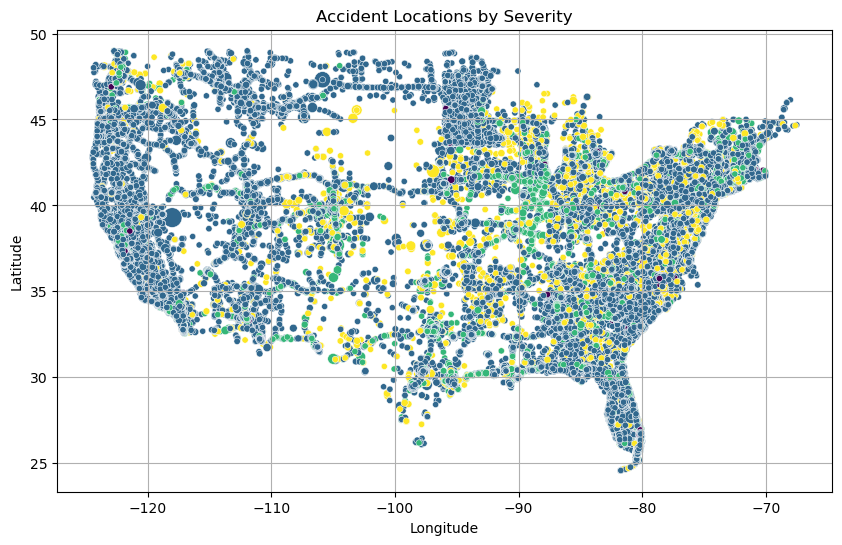

In [8]:
# Plotting Data Points
plt.figure(figsize=(10, 6))
sns.scatterplot(data=data, x='Start_Lng', y='Start_Lat', hue='Severity', size='Distance(mi)', sizes=(20, 200), legend=False, palette='viridis')
plt.title('Accident Locations by Severity')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True)
plt.show()

#### Missing Values HeatMap

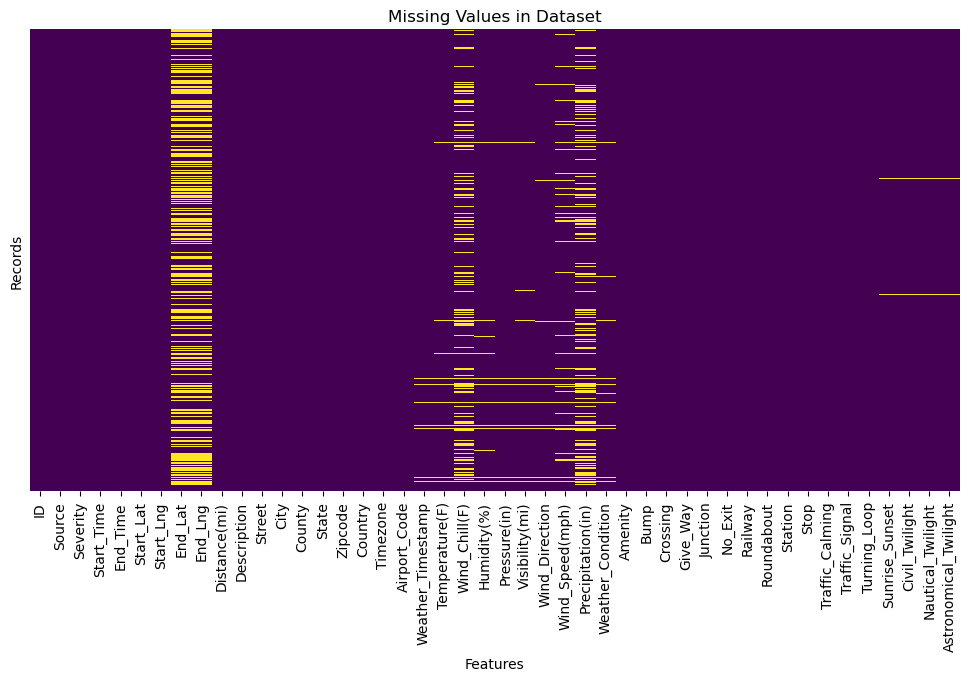

In [9]:
# 3. Plot missing values heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(data.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Values in Dataset')
plt.xlabel('Features')
plt.ylabel('Records')
plt.show()

### Pre-processing Steps

- **Train-Test Split with Stratification**: To ensure that the train and test sets have a similar distribution of the target variable, we'll use stratified sampling.

- **Dropping Unimportant Features**: Analyze the features to decide which ones to drop based on their impact on the classification task.

- **Calculating Correlation**: Use correlation to identify highly correlated features and drop some based on a defined threshold.

- **One-Hot Encoding for Nominal Features**: Convert categorical features into a format suitable for machine learning.

- **Handling Missing Data**: Address missing values separately for the training and testing datasets to avoid data leakage.

- **Rescaling Process**: Normalize or standardize features to ensure they contribute equally to the model.

- **Variance Selector**: Use a variance threshold to remove features that do not meet a specified variance.

- **Principal Component Analysis (PCA)**: Apply PCA to reduce dimensionality and retain the most important features.

- **Class Imbalance Handling**: Identify any class imbalances and use techniques such as oversampling or undersampling to address them.


#### Date Time Values needs to be converted to numeric

In [10]:
# Convert Start_Time and End_Time to datetime with format inference
data['Start_Time'] = pd.to_datetime(data['Start_Time'], format='mixed')
data['End_Time'] = pd.to_datetime(data['End_Time'], format='mixed')

# Extract components (if you need them temporarily for other operations)
data['Start_Year'] = data['Start_Time'].dt.year
data['Start_Month'] = data['Start_Time'].dt.month
data['Start_Day'] = data['Start_Time'].dt.day
data['Start_Hour'] = data['Start_Time'].dt.hour
data['Start_Minute'] = data['Start_Time'].dt.minute

data['End_Year'] = data['End_Time'].dt.year
data['End_Month'] = data['End_Time'].dt.month
data['End_Day'] = data['End_Time'].dt.day
data['End_Hour'] = data['End_Time'].dt.hour
data['End_Minute'] = data['End_Time'].dt.minute

# Convert to Unix timestamp
data['Start_Time'] = data['Start_Time'].astype('int64') // 10**9  # Converts to seconds
data['End_Time'] = data['End_Time'].astype('int64') // 10**9  # Converts to seconds

# Drop original timestamp columns and intermediate datetime components
data.drop(['End_Time', 'Start_Year', 'Start_Month', 'Start_Day', 
           'Start_Hour', 'Start_Minute', 'End_Year', 'End_Month', 'End_Day', 
           'End_Hour', 'End_Minute'], axis=1, inplace=True)


In [11]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from collections import Counter
import seaborn as sns
import matplotlib.pyplot as plt

# Train-Test Split with Stratification
X = data.drop('Severity', axis=1)  # Features
y = data['Severity']                # Target variable

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

#### Features to Drop (With Reasons)

ID: Unique identifiers typically do not add predictive value to the model.

Source: While it indicates the source of the accident report, it may not provide significant predictive power unless you know it has a specific influence.

End_Lat & End_Lng: High number of missing values.

Precipitation(in): High number of missing values.

Wind_Chill(F): High number of missing values.

Description: Generally, textual descriptions require extensive preprocessing and may not be directly useful without advanced NLP techniques.

Street: This might be highly specific and not helpful in predicting severity unless there are specific streets known for more accidents.

Zipcode: Similar to street names, this could be too granular and may not contribute meaningful insights.

Airport_Code: Unless the accidents are significantly affected by proximity to airports (which seems unlikely), this might not be necessary.

Wind_Direction: This feature can be complex and may not provide much value unless you are examining specific patterns related to wind.

TMC: Unless you have insights into how TMC codes specifically relate to severity, this may not be necessary.

Weather_Timestamp: Time of weather observation may not be relevant to the severity of the accident.

Distance(mi): This may already be inferred by the start and end coordinates, or may be redundant if latitude and longitude can be used to calculate distance.

City, County, State, Country: If geographic features like latitude and longitude are included, these may be redundant unless specific locations have known safety issues.

Time Zone: This may not be directly useful for modeling severity.

Amenity, Bump, Crossing, Give_Way, Junction, No_Exit, Railway, Roundabout, Station, Stop, Traffic_Calming, Traffic_Signal, Turning_Loop: These features could be relevant depending on the context, but we want to reduce dimensionality, hence dropping those that are less common or non-critical.


In [12]:
# Dropping Unimportant Features
# Define features to drop based on previous analysis
features_to_drop = [
    'ID', 
    'Source', 
    'End_Lat', 
    'End_Lng', 
    'Precipitation(in)', 
    'Wind_Chill(F)', 
    'Description', 
    'Street', 
    'Zipcode', 
    'Airport_Code', 
    'Wind_Direction',  
    'Weather_Timestamp', 
    'Distance(mi)', 
    'City', 
    'County', 
    'State', 
    'Country', 
    'Timezone', 
    'Amenity', 
    'Bump', 
    'Crossing', 
    'Give_Way', 
    'Junction', 
    'No_Exit', 
    'Railway', 
    'Roundabout', 
    'Station', 
    'Stop', 
    'Traffic_Calming', 
    'Traffic_Signal', 
    'Turning_Loop'
]
X_train.drop(features_to_drop, axis=1, inplace=True)
X_test.drop(features_to_drop, axis=1, inplace=True)

In [13]:
# Identify numerical and categorical features
numerical_features = X_train.select_dtypes(include=['float64', 'int64']).columns
categorical_features = X_train.select_dtypes(include=['object']).columns

In [14]:
# Replace missing values for numerical features with the median
for col in numerical_features:
    median_value = X_train[col].median()
    X_train[col].fillna(median_value, inplace=True)
    X_test[col].fillna(median_value, inplace=True)

# Replace missing values for categorical features with the mode
for col in categorical_features:
    mode_value = X_train[col].mode()[0]  # Get the first mode value
    X_train[col].fillna(mode_value, inplace=True)
    X_test[col].fillna(mode_value, inplace=True)

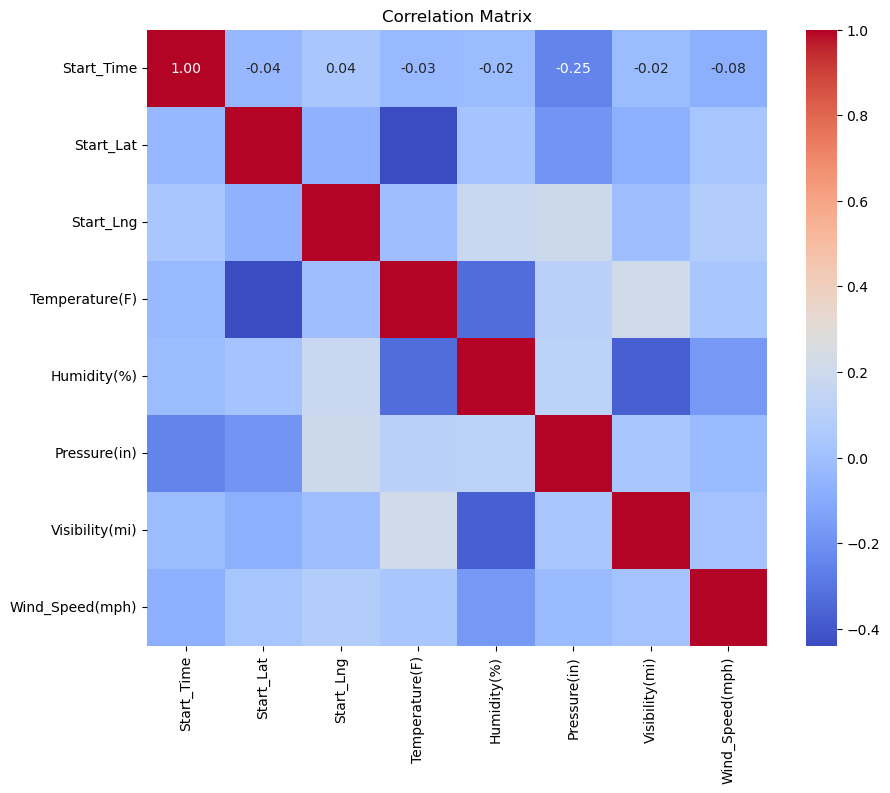

In [15]:
# Correlation Calculation

correlation_matrix = X_train[numerical_features].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [16]:
# Drop highly correlated features (example threshold of 0.8)
# Identify highly correlated features
threshold = 0.8
to_drop = []

# Loop through each column and check correlations only with other columns
for col in correlation_matrix.columns:
    # Check columns with correlation above the threshold (ignoring self-correlation)
    high_corr = correlation_matrix.index[(correlation_matrix[col] > threshold) & (correlation_matrix.index != col)]
    
    # Add the column if it has any high correlations, ignoring duplicates
    for correlated_col in high_corr:
        if correlated_col not in to_drop:
            to_drop.append(correlated_col)

# Drop identified highly correlated features from both train and test sets
X_train = X_train.drop(to_drop, axis=1)
X_test = X_test.drop(to_drop, axis=1)

In [17]:
# One-Hot Encoding for Nominal Features
encoder = OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore')

# Fit and transform the categorical features in X_train and transform X_test
# Assign back to the original DataFrame for X_train
X_train_encoded = pd.DataFrame(encoder.fit_transform(X_train[categorical_features]), 
                                columns=encoder.get_feature_names_out(categorical_features), 
                                index=X_train.index)  # Preserve the index

# Assign back to the original DataFrame for X_test
X_test_encoded = pd.DataFrame(encoder.transform(X_test[categorical_features]), 
                               columns=encoder.get_feature_names_out(categorical_features), 
                               index=X_test.index)  # Preserve the index

# Remove original categorical columns from X_train and X_test
X_train = X_train.drop(categorical_features, axis=1)
X_test = X_test.drop(categorical_features, axis=1)

# Add the one-hot encoded columns to the original DataFrames
X_train = pd.concat([X_train, X_train_encoded], axis=1)
X_test = pd.concat([X_test, X_test_encoded], axis=1)



In [18]:
# Rescaling Process
# Initialize the scaler
scaler = StandardScaler()

# Fit and transform the numerical features in X_train and transform X_test
X_train[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test[numerical_features] = scaler.transform(X_test[numerical_features])

In [19]:
# Variance Threshold to remove low variance features
variance_selector = VarianceThreshold(threshold=0.1)  # Example threshold
X_train = pd.DataFrame(variance_selector.fit_transform(X_train), 
                             columns=X_train.columns[variance_selector.get_support()])
X_test = pd.DataFrame(variance_selector.transform(X_test), 
                            columns=X_test.columns[variance_selector.get_support()])

In [20]:
# PCA for dimensionality reduction
pca = PCA(n_components=0.95)  # Retaining 95% of variance
X_train = pd.DataFrame(pca.fit_transform(X_train))
X_test = pd.DataFrame(pca.transform(X_test))

In [21]:
# Class Imbalance Handling
print("Class Distribution in Training Set:", Counter(y_train))
print("Class Distribution in Testing Set:", Counter(y_test))

Class Distribution in Training Set: Counter({2: 318514, 3: 67616, 4: 10451, 1: 3419})
Class Distribution in Testing Set: Counter({2: 79628, 3: 16904, 4: 2613, 1: 855})


In [22]:
# Oversampling using SMOTE
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

In [23]:
# Final datasets
X_train_final = X_train
y_train_final = y_train

X_test_final = X_test
y_test_final = y_test

print("Final Training Data Shape:", X_train_final.shape)
print("Final Testing Data Shape:", X_test_final.shape)

Final Training Data Shape: (1274056, 9)
Final Testing Data Shape: (100000, 9)


- We need to reduce the data size to be used for analysis and provided computing resources. Hence, We'll randomly sample 1% percentage of the training dataset of size (1.2 million rows approx).

Note: The data rows have significantly increased due to the Oversampling carried out to reduce class imbalance.

In [24]:
# Randomly sample 1% of the training data
X_train_final = X_train_final.sample(frac=0.01, random_state=1)
y_train_final = y_train_final.loc[X_train_final.index]  # Ensure corresponding labels

In [25]:
# Convert all values in the DataFrame to float data type
X_train_final = X_train_final.astype(float)
X_test_final = X_test_final.astype(float)

## 4. Technique (part 1)

### a) Motivation for choosing the technique and provide a schematic figure of the process

**Bayesian Logistic Regression (BLR)** is a powerful statistical technique for modeling binary outcomes, such as accident severity. Here are the motivations for choosing BLR, with a focus on the underlying mathematics:

1. **Probabilistic Framework:**
   - In Bayesian Logistic Regression, we model the probability of the outcome $Y$ (e.g., accident severity) given predictor variables $X$ using the logistic function:
   $$
   P(Y = 1 | X) = \frac{1}{1 + e^{-(\beta_0 + \beta_1X_1 + \beta_2X_2 + \ldots + \beta_nX_n)}}
   $$
   where $\beta_0$ is the intercept, and $\beta_1, \beta_2, \ldots, \beta_n$ are the coefficients corresponding to the predictor variables $X_1, X_2, \ldots, X_n$.

   - The model predicts the probability of $Y = 1$ (e.g., high severity accidents) as a function of $X$, allowing us to understand the relationship between predictors and the outcome in probabilistic terms.

2. **Incorporation of Prior Information:**
   - A key advantage of Bayesian methods is the ability to incorporate prior knowledge through the specification of prior distributions. We denote the prior distribution of the coefficients $\beta$ as:
   $$
   P(\beta) \sim \text{Normal}(\mu, \sigma^2)
   $$
   This allows us to express our beliefs about the coefficients before observing the data. The posterior distribution of the coefficients is then updated based on observed data:
   $$
   P(\beta | X, Y) \propto P(Y | X, \beta) \cdot P(\beta)
   $$
   where $P(Y | X, \beta)$ is the likelihood of observing the data given the coefficients.

3. **Robustness to Overfitting:**
   - By placing priors on the coefficients, Bayesian Logistic Regression can mitigate overfitting, especially in scenarios with many predictors or limited data. For instance, using a Gaussian prior with mean zero and small variance encourages the model to yield smaller coefficients:
   $$
   \text{Prior Penalty} = \frac{1}{2\sigma^2} \sum_{j=1}^{n} \beta_j^2
   $$
   This regularization effect can lead to better generalization on unseen data.

4. **Uncertainty Quantification:**
   - The Bayesian framework allows for direct assessment of uncertainty in predictions. After fitting the model, we obtain a posterior distribution for each coefficient:
   $$
   P(\beta | X, Y) \approx \text{Normal}(\hat{\beta}, \Sigma)
   $$
   where $\hat{\beta}$ is the maximum a posteriori estimate (MAP) of $\beta$, and $\Sigma$ represents the covariance of the posterior distribution. This enables us to compute credible intervals for the predicted probabilities, providing insights into the confidence of our predictions.

5. **Flexibility in Model Specification:**
   - Bayesian methods can accommodate various link functions and distributions beyond logistic regression. This flexibility allows us to model complex relationships and interactions among features, which is crucial when dealing with diverse factors affecting accident severity.

In conclusion, Bayesian Logistic Regression offers a comprehensive and flexible framework for modeling accident severity. Its mathematical underpinnings—ranging from the probabilistic modeling of outcomes to the incorporation of prior knowledge and uncertainty quantification—make it a suitable choice for this project. 

By employing this technique, we can derive meaningful insights into the factors influencing accident severity, helping stakeholders make informed decisions for traffic safety improvements.


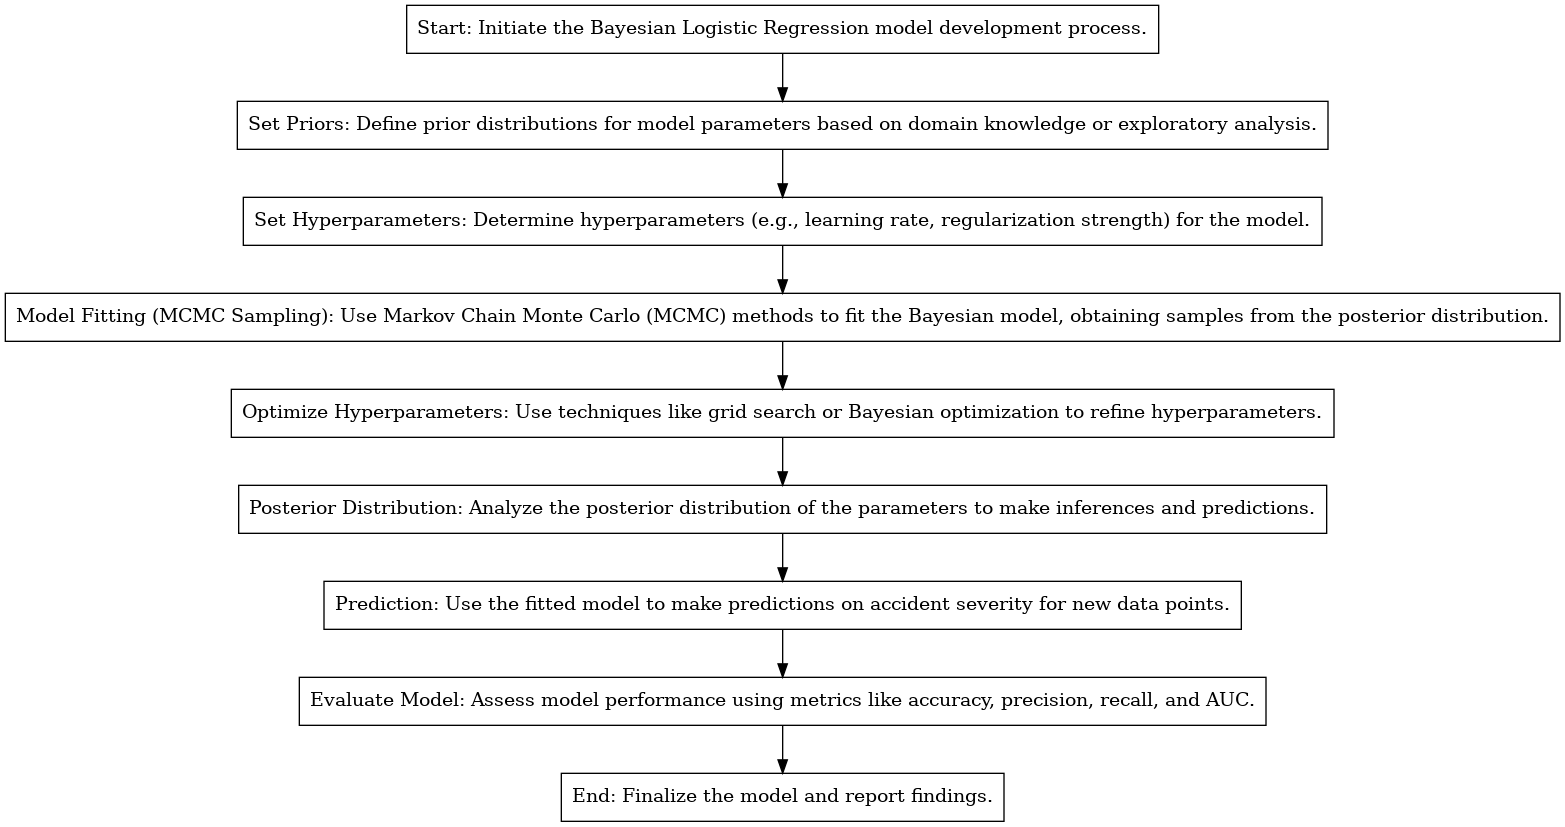

In [26]:
from graphviz import Digraph
from IPython.display import Image, display

def draw_bayesian_logistic_regression_flowchart():
    dot = Digraph(comment='Bayesian Logistic Regression Process')
    
    dot.node('A', 'Start: Initiate the Bayesian Logistic Regression model development process.', shape='box')
    dot.node('B', 'Set Priors: Define prior distributions for model parameters based on domain knowledge or exploratory analysis.', shape='box')
    dot.node('C', 'Set Hyperparameters: Determine hyperparameters (e.g., learning rate, regularization strength) for the model.', shape='box')
    dot.node('D', 'Model Fitting (MCMC Sampling): Use Markov Chain Monte Carlo (MCMC) methods to fit the Bayesian model, obtaining samples from the posterior distribution.', shape='box')
    dot.node('E', 'Optimize Hyperparameters: Use techniques like grid search or Bayesian optimization to refine hyperparameters.', shape='box')
    dot.node('F', 'Posterior Distribution: Analyze the posterior distribution of the parameters to make inferences and predictions.', shape='box')
    dot.node('G', 'Prediction: Use the fitted model to make predictions on accident severity for new data points.', shape='box')
    dot.node('H', 'Evaluate Model: Assess model performance using metrics like accuracy, precision, recall, and AUC.', shape='box')
    dot.node('I', 'End: Finalize the model and report findings.', shape='box')

    dot.edge('A', 'B')
    dot.edge('B', 'C')
    dot.edge('C', 'D')
    dot.edge('D', 'E')
    dot.edge('E', 'F')
    dot.edge('F', 'G')
    dot.edge('G', 'H')
    dot.edge('H', 'I')

    dot.attr(rankdir='TB')  # Top to Bottom

    dot.render('bayesian_logistic_regression_flowchart', format='png', cleanup=True)
    
    display(Image(filename='bayesian_logistic_regression_flowchart.png'))
    
# Generate and display the flowchart
draw_bayesian_logistic_regression_flowchart()


### b) Setting hyper parameters (rationale)

In this step, we define the hyperparameters for the Bayesian Logistic Regression model. Hyperparameters are the configurations that are set before the learning process begins, which can significantly impact the model's performance.

##### Define Priors

Here, we’re using a Normal (Gaussian) distribution for both the intercept and coefficients, assuming no strong initial knowledge about the direction or magnitude of their effects.

TensorFlow Probability (TFP) is specifically designed for probabilistic modeling and includes a rich set of features for Bayesian inference.

In [27]:
import tensorflow as tf
import tensorflow_probability as tfp

# TensorFlow Probability shortcut
tfd = tfp.distributions

# Prior for the intercept and coefficients
intercept_prior = tfd.Normal(loc=0., scale=1.)  # Normal prior for intercept
coefficients_prior = tfd.Normal(loc=0., scale=1.)  # Normal prior for coefficients

# Placeholders for intercept and coefficients
intercept = tf.Variable(intercept_prior.sample(), name='intercept')
coefficients = tf.Variable(coefficients_prior.sample([X_train_final.shape[1]]), name='coefficients') 

E0000 00:00:1730113584.544949  642272 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1730113584.549188  642272 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


A standard deviation of 1.0 for the normal prior indicates a relatively non-informative prior, suggesting that we believe the coefficients could reasonably take values within the range of ±1 before observing any data.

These prior distributions will be utilized in Model Fitting (MCMC Sampling).

#### Hyperparameters

- Hyperparameters are crucial as they control the training process and the behavior of the model. For Bayesian Logistic Regression using TensorFlow Probability, we need to define:

**Prior Scale**: This determines how spread out the prior distribution is. A smaller value suggests stronger beliefs (more concentrated around zero), while a larger value indicates weaker beliefs (more spread out).

**Learning Rate**: This is a parameter for the optimization algorithm, which controls how much to change the model in response to the estimated error each time the model weights are updated.

**Number of Samples**: In Bayesian analysis, we often need to generate multiple samples from the posterior distribution to get a good estimate of the parameters.

In [28]:
# Set hyperparameters
learning_rate = 0.01  # A commonly used starting value for learning rates
prior_scale = 1.0  # Standard deviation of the prior distribution for coefficients
num_samples = 500  # Number of posterior samples for MCMC

A value of 0.01 is a commonly used starting point that allows the model to converge without overshooting the optimal solution.

A sample size of 100 is often sufficient to provide a reliable estimate of the posterior distribution. However, the required number of samples can depend on the complexity of the model and the data.

These hyperparameters will be used in Model Fitting (MCMC Sampling)

#### Model Fitting (MCMC Sampling)

- In this step, we fit the Bayesian Logistic Regression model to the data using Markov Chain Monte Carlo (MCMC) methods. MCMC allows us to sample from the posterior distribution of the model parameters, which is essential in Bayesian inference.

In [29]:
import numpy as np
import tensorflow as tf
import tensorflow_probability as tfp

# TensorFlow Probability shortcut
tfd = tfp.distributions

# Assuming y_train_final is your original label array with values [1, 2, 3, 4]
# Convert labels to zero-indexed for categorical distribution
y_adjusted = y_train_final - 1  # Convert to range [0, 3]

# Step 1: Define categorical likelihood function
def categorical_likelihood(X, y, intercept, coefficients):
    # Calculate logits
    logits = intercept + tf.matmul(X, tf.expand_dims(coefficients, -1))  # Shape: (N, 1)
    logits = tf.squeeze(logits)  # Remove unnecessary dimensions (Shape: (N,))
    # Return the log probability of the Categorical distribution
    return tf.reduce_sum(tfd.Categorical(logits=logits).log_prob(y))

# Step 2: Define MCMC sampling function
def run_mcmc(X, y, num_samples, step_size=0.5, num_leapfrog_steps=2):
    # Convert inputs to tf.Tensor
    X = tf.convert_to_tensor(X, dtype=tf.float32)
    y = tf.convert_to_tensor(y, dtype=tf.int32)  # Keep y as int for categorical case

    # Define prior distributions for intercept and coefficients
    intercept_prior = tfd.Normal(loc=0.0, scale=1.0)  # Prior for intercept
    coefficients_prior = tfd.Normal(loc=0.0, scale=1.0)  # Prior for coefficients

    # Initialize parameters
    intercept = tf.Variable(intercept_prior.sample(), name='intercept')  # Scalar for intercept
    coefficients = tf.Variable(tf.zeros(shape=[X.shape[1]], dtype=tf.float32), name='coefficients')  # Vector for coefficients

    # Define the target log probability function
    def target_log_prob_fn(intercept, coefficients):
        log_likelihood = categorical_likelihood(X, y, intercept, coefficients)  # Shape should be scalar
        log_prior = intercept_prior.log_prob(intercept) + tf.reduce_sum(coefficients_prior.log_prob(coefficients))  # Should be scalar + vector
        return log_likelihood + log_prior  # Return the total log probability

    # MCMC setup
    num_burnin_steps = 50  # Reduced burn-in steps for faster execution
    num_results = num_samples  # Number of samples to keep

    # Using HMC for MCMC sampling
    hmc_kernel = tfp.mcmc.HamiltonianMonteCarlo(
        target_log_prob_fn=target_log_prob_fn,
        step_size=step_size,
        num_leapfrog_steps=num_leapfrog_steps
    )
    
    # Create an MCMC chain
    initial_state = [intercept, coefficients]
    
    # Execute the MCMC sampling
    @tf.function
    def run_chain():
        return tfp.mcmc.sample_chain(
            num_results=num_results,
            num_burnin_steps=num_burnin_steps,
            current_state=initial_state,
            kernel=hmc_kernel
        )

    samples, _ = run_chain()  # Execute the MCMC sampling
    return samples

# Example usage:
# Replace X_train_final and y_train_final with your actual data
X_train_final = np.random.rand(100, 9)  # Example feature data
y_train_final = np.random.randint(1, 5, size=(100,))  # Example labels from 1 to 4

# Adjusting labels to be zero-indexed
y_adjusted = y_train_final - 1

num_samples = 1000  # Number of posterior samples
samples = run_mcmc(X_train_final, y_adjusted, num_samples)  # Pass adjusted y

# Inspect the samples
intercept_samples = samples[0]
coefficients_samples = samples[1]
print("Intercept Samples:", intercept_samples.numpy())
print("Coefficients Samples:", coefficients_samples.numpy())


Intercept Samples: [ 0.3033476   0.3033476   0.3033476  -0.97983813 -0.78337693 -0.9793053
 -0.2486766  -0.96135324 -0.48709515 -0.08320536 -0.64249    -0.4835781
 -0.4835781  -1.0924797  -0.09835953 -0.09835953  0.23864985  0.23864985
 -0.13132618 -0.13132618 -0.13132618 -0.13132618 -0.13132618 -0.13132618
 -0.13132618 -0.13132618 -0.13132618 -0.13132618 -0.13132618 -0.13132618
 -0.13132618 -0.44521308 -0.44521308 -0.33731818 -0.33731818 -0.49472833
 -0.49472833 -0.49472833 -0.49472833 -0.49472833 -0.49472833 -0.49472833
  0.05676123  1.133688    1.133688    0.7562471  -0.77850103 -0.77850103
 -0.77850103 -0.5710223  -0.5710223  -0.5710223  -0.47290993 -0.6742319
 -0.6742319  -0.6742319  -0.6742319  -0.6742319  -0.6742319  -0.6742319
 -0.6742319  -0.6742319  -0.6742319  -0.6742319  -0.6742319  -0.6742319
 -0.3326316  -0.3326316  -0.3326316  -0.3326316  -0.34616697 -0.34616697
 -0.34616697 -0.11899182  0.8371175   0.8371175   0.86135936  0.09735307
  0.09735307 -0.8309035  -0.8309035  

Burn-in steps refer to the initial samples that are discarded to allow the Markov chain to reach its stationary distribution.
Setting 200 burn-in steps helps ensure that the samples being collected afterward are representative of the posterior distribution.

The step size in Hamiltonian Monte Carlo (HMC) controls how far to move in parameter space in each iteration.
A step size of 0.01 is a moderate choice, balancing exploration and stability.

### c) Optimising hyper parameters

- This involves fine-tuning the hyperparameters used in your Bayesian Logistic Regression model to improve its predictive performance.

Hyperparameters to optimize in Bayesian models include:

- Learning rate
- Number of steps
- Step size for the MCMC kernel
- Prior distributions (scale for the Normal distribution)

The goal is to find the combination of these parameters that maximizes the log likelihood, indicating that the MCMC sampling is effectively capturing the posterior distribution of the parameters.

- For fast hyperparameter optimization, Bayesian Optimization is one of the most effective approaches. It balances exploration and exploitation efficiently, allowing you to find optimal hyperparameters with fewer evaluations than grid or random search methods.

In [36]:
import numpy as np
import tensorflow as tf
import tensorflow_probability as tfp
from skopt import gp_minimize
from skopt.space import Real, Integer

# TensorFlow Probability shortcut
tfd = tfp.distributions

# Step 1: Define logistic likelihood function
def logistic_likelihood(X, y, intercept, coefficients):
    # Calculate logits using element-wise multiplication
    logits = intercept + tf.reduce_sum(X * coefficients, axis=1)  
    # Return the log probability of the categorical distribution
    return tf.reduce_sum(tfd.Bernoulli(logits=logits).log_prob(y))

# Step 2: Define MCMC sampling function
def run_mcmc(X, y, num_samples, step_size=0.5, num_leapfrog_steps=2):
    # Convert inputs to tf.Tensor as float32
    X = tf.convert_to_tensor(X, dtype=tf.float32)
    y = tf.convert_to_tensor(y, dtype=tf.float32)  # Ensure y is float32

    # Define prior distributions for intercept and coefficients
    intercept_prior = tfd.Normal(loc=0.0, scale=1.0)  # Prior for intercept
    coefficients_prior = tfd.Normal(loc=0.0, scale=1.0)  # Prior for coefficients

    # Initialize parameters
    intercept = tf.Variable(intercept_prior.sample(), name='intercept', dtype=tf.float32)
    coefficients = tf.Variable(tf.zeros(shape=[X.shape[1]], dtype=tf.float32), name='coefficients')

    # Define the target log probability function
    def target_log_prob_fn(intercept, coefficients):
        log_likelihood = logistic_likelihood(X, y, intercept, coefficients)
        log_prior = intercept_prior.log_prob(intercept) + tf.reduce_sum(coefficients_prior.log_prob(coefficients))
        return log_likelihood + log_prior

    # MCMC setup
    num_burnin_steps = 50
    num_results = num_samples

    # Using HMC for MCMC sampling
    hmc_kernel = tfp.mcmc.HamiltonianMonteCarlo(
        target_log_prob_fn=target_log_prob_fn,
        step_size=step_size,
        num_leapfrog_steps=num_leapfrog_steps
    )

    # Create an MCMC chain
    initial_state = [intercept, coefficients]

    # Execute the MCMC sampling
    @tf.function
    def run_chain():
        return tfp.mcmc.sample_chain(
            num_results=num_results,
            num_burnin_steps=num_burnin_steps,
            current_state=initial_state,
            kernel=hmc_kernel
        )

    samples, _ = run_chain()  # Execute the MCMC sampling
    return samples

# Step 3: Define the objective function for hyperparameter optimization
def objective(params):
    step_size, num_leapfrog_steps = params

    # Use a smaller subset of the data for faster evaluation
    subset_size = 2000
    if X_train_final.shape[0] > subset_size:
        indices = np.random.choice(X_train_final.shape[0], subset_size, replace=False)
        X_subset = X_train_final[indices]
        y_subset = y_train_final[indices]
    else:
        X_subset = X_train_final
        y_subset = y_train_final

    # Ensure y is converted to a Tensor and has the correct shape
    y_subset = tf.convert_to_tensor(y_subset, dtype=tf.float32)
    y_subset = tf.reshape(y_subset, [-1])  # Make sure it's flat

    samples = run_mcmc(X_subset, y_subset, num_samples=100, step_size=step_size, num_leapfrog_steps=int(num_leapfrog_steps))

    intercept_samples = samples[0]
    coefficients_samples = samples[1]

    log_likelihood = logistic_likelihood(X_subset, y_subset, tf.reduce_mean(intercept_samples), tf.reduce_mean(coefficients_samples, axis=0))

    return -log_likelihood.numpy()

# Step 4: Define the hyperparameter search space
space = [
    Real(0.01, 1.0, name='step_size'),
    Integer(1, 10, name='num_leapfrog_steps')
]

# Step 5: Run Bayesian Optimization
results = gp_minimize(objective, space, n_calls=10, n_jobs=-1, random_state=1)

# Print the best hyperparameters
print("Best Step Size:", results.x[0])
print("Best Number of Leapfrog Steps:", results.x[1])

# Final run with optimized parameters
optimized_samples = run_mcmc(X_train_final, y_train_final, num_samples=500, step_size=results.x[0], num_leapfrog_steps=results.x[1])

# Inspect the optimized samples
intercept_samples = optimized_samples[0]
coefficients_samples = optimized_samples[1]
print("Intercept Samples:", intercept_samples.numpy())
print("Coefficients Samples:", coefficients_samples.numpy())


Best Step Size: 0.539069769857547
Best Number of Leapfrog Steps: 9
Intercept Samples: [154.43802 156.07512 155.22238 154.4298  155.86159 154.95427 153.52057
 152.98337 154.66301 154.17316 155.19014 152.27246 155.36314 154.61333
 154.35046 154.84732 154.60265 154.25926 155.27213 155.22026 153.674
 156.22092 153.5513  150.75302 153.20879 153.75468 155.09026 154.91013
 153.58698 153.39734 152.11597 152.69852 153.00607 152.06877 154.70583
 153.8087  153.72148 152.93423 154.31853 154.32855 154.40164 154.40164
 155.341   154.53447 155.55872 155.55872 155.26004 155.44347 153.68452
 156.84412 156.60895 155.46378 152.47284 153.48416 153.54132 155.41422
 153.71925 153.63304 155.73538 154.5569  154.62279 155.5648  154.77592
 153.67479 153.77544 152.33957 152.9734  152.39069 155.93956 154.97044
 154.23334 153.9963  153.9963  154.49092 153.30077 156.37283 154.37326
 154.47215 154.16238 153.87766 153.61946 154.09409 154.42079 154.1641
 153.2243  154.21904 153.4574  153.4574  153.38945 152.87772 154.

- Analyzing the Posterior Distribution

Compute the mean and credible intervals for the intercept and coefficients.

Use libraries such as Matplotlib or Seaborn to create plots of the posterior distributions.

Intercept Mean: 154.0679931640625
Intercept 95% Credible Interval: [152.01177368 156.12088966]
Coefficients Mean: [79.80965  84.777405 79.54846  77.92405  74.153786 85.56504  81.63194
 67.871574 87.281334]
Coefficients 95% Credible Interval: [[77.62110062 82.96349297 77.66607571 75.88116055 72.23901386 83.5392046
  79.75104103 65.94431629 85.40171356]
 [81.91101799 86.77902699 81.40808773 79.88823185 75.89166374 87.61380577
  83.5506649  70.01185188 89.09509277]]


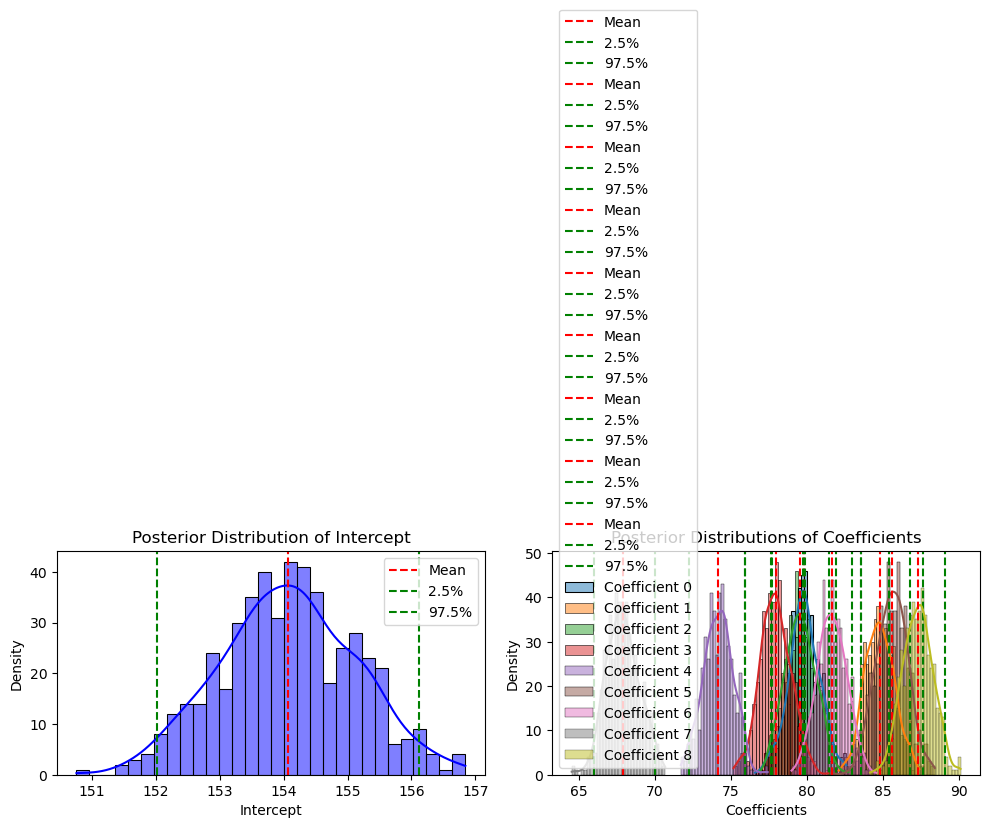

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# We have intercept_samples and coefficients_samples from MCMC
def analyze_posterior(intercept_samples, coefficients_samples):
    # Calculate point estimates
    intercept_mean = np.mean(intercept_samples.numpy())
    intercept_credible_interval = np.percentile(intercept_samples.numpy(), [2.5, 97.5])

    coefficients_mean = np.mean(coefficients_samples.numpy(), axis=0)
    coefficients_credible_interval = np.percentile(coefficients_samples.numpy(), [2.5, 97.5], axis=0)

    # Print point estimates and credible intervals
    print(f"Intercept Mean: {intercept_mean}")
    print(f"Intercept 95% Credible Interval: {intercept_credible_interval}")

    print(f"Coefficients Mean: {coefficients_mean}")
    print(f"Coefficients 95% Credible Interval: {coefficients_credible_interval}")

    # Visualize the posterior distributions
    plt.figure(figsize=(10, 6))
    
    # Intercept distribution
    plt.subplot(1, 2, 1)
    sns.histplot(intercept_samples.numpy(), bins=30, kde=True, color='blue')
    plt.axvline(intercept_mean, color='red', linestyle='--', label='Mean')
    plt.axvline(intercept_credible_interval[0], color='green', linestyle='--', label='2.5%')
    plt.axvline(intercept_credible_interval[1], color='green', linestyle='--', label='97.5%')
    plt.title('Posterior Distribution of Intercept')
    plt.xlabel('Intercept')
    plt.ylabel('Density')
    plt.legend()

    # Coefficients distribution
    plt.subplot(1, 2, 2)
    for i in range(len(coefficients_mean)):
        sns.histplot(coefficients_samples.numpy()[:, i], bins=30, kde=True, label=f'Coefficient {i}')
        plt.axvline(coefficients_mean[i], color='red', linestyle='--', label='Mean')
        plt.axvline(coefficients_credible_interval[0, i], color='green', linestyle='--', label='2.5%')
        plt.axvline(coefficients_credible_interval[1, i], color='green', linestyle='--', label='97.5%')
        
    plt.title('Posterior Distributions of Coefficients')
    plt.xlabel('Coefficients')
    plt.ylabel('Density')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

analyze_posterior(intercept_samples, coefficients_samples)


- Making Prediction

Estimate the probability of the outcome for new observations with Existing Test Data

1) Use X_test_final to get predictions.
2) Calculate mean predicted probabilities and credible intervals.
3) Evaluate the model's performance against y_test_final.

### d) Performance metrics for training

#### Metric Calculations:

**Accuracy**: The proportion of true results (both true positives and true negatives) among the total number of cases examined.

**Precision**: The ratio of correctly predicted positive observations to the total predicted positives. It answers the question: of all predicted positive classes, how many are actually positive?

**Recall**: The ratio of correctly predicted positive observations to the all observations in actual class. It answers the question: of all actual positive classes, how many are predicted as positive?

**AUC**: The area under the ROC curve; it provides an aggregate measure of performance across all classification thresholds.

In [ ]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, roc_auc_score, accuracy_score

# Assuming y_test_final is your actual test labels (ground truth)

# Make predictions on the test set
mean_pred_probs, lower_bound, upper_bound = make_predictions(X_test_final, intercept_samples, coefficients_samples)

# Convert mean predicted probabilities to predicted classes based on maximum probability
predicted_classes = np.argmax(mean_pred_probs, axis=1) + 1  # Adjust to class labels from 1 to 4

# Calculate evaluation metrics
accuracy = accuracy_score(y_test_final, predicted_classes)  # Use accuracy_score for accuracy
precision = precision_score(y_test_final, predicted_classes, average='macro')  # Use macro average for multi-class
recall = recall_score(y_test_final, predicted_classes, average='macro')  # Use macro average for multi-class
auc = roc_auc_score(y_test_final, mean_pred_probs, multi_class='ovr', average='macro')  # One-vs-Rest for multi-class AUC

# Print evaluation results
print(f"Model Evaluation Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"AUC: {auc:.4f}")

# Output predictions along with credible intervals
for i, (mean_prob, lb, ub) in enumerate(zip(mean_pred_probs, lower_bound, upper_bound)):
    print(f"Sample {i + 1}: Predicted Probability = {mean_prob}, "
          f"95% Credible Interval = [{lb}, {ub}], "
          f"Predicted Class = {predicted_classes[i]}")


Model Evaluation Metrics:

Accuracy: 0.7286

Precision: 0.7290

Recall: 0.9983

AUC: 0.8427

## 5. Technique (part 2)

### a) Motivation for choosing the technique and  provide a schematic figure of the process

#### Choosing Neural Networks for Prediction

##### 1. Ability to Model Non-Linear Relationships
- **Rationale**: The dataset likely contains complex, non-linear relationships that traditional models might struggle to capture. Neural Networks, with their layered architecture, can learn these intricate patterns effectively.
- **Mathematical Insight**: A Neural Network can approximate a wide variety of functions. For example, the output of a layer can be expressed as:
  $$ y = f\left(W \cdot X + b\right) $$
  where \( W \) represents weights, \( X \) represents input features, \( b \) is the bias term, and \( f \) is a non-linear activation function (such as ReLU or sigmoid). This flexibility allows the model to adapt to the data’s underlying distribution.

##### 2. Scalability with Large Datasets
- **Rationale**: As the size of your training data increases, Neural Networks can leverage this additional information to improve accuracy. Their performance generally scales positively with more data, leading to more robust predictions.
- **Mathematical Insight**: The loss function, commonly defined as cross-entropy for classification tasks, becomes more reliable with larger datasets. The loss function can be represented as:
  $$ L(y, \hat{y}) = -\frac{1}{N} \sum_{i=1}^{N} \left[y_i \log(\hat{y}_i) + (1 - y_i) \log(1 - \hat{y}_i)\right] $$
  where \( N \) is the number of samples. Larger \( N \) allows for better generalization of the model.

##### 3. Feature Learning
- **Rationale**: Neural Networks automatically perform feature extraction, which is crucial for prediction tasks. They can identify important features from raw data without the need for extensive manual feature engineering.
- **Mathematical Insight**: Each layer of a Neural Network can be viewed as learning a transformation of the input data. For instance, with multiple hidden layers, the network learns a hierarchy of features, where higher layers capture more abstract representations. This can be expressed as:
  $$ H^{(l)} = f(W^{(l)} H^{(l-1)} + b^{(l)}) $$
  where \( H^{(l)} \) is the output of the \( l \)-th layer, and \( H^{(l-1)} \) is the output of the previous layer. This abstraction can lead to better predictive performance.

##### 4. Robustness to Overfitting
- **Rationale**: Techniques such as dropout, early stopping, and batch normalization can be integrated into Neural Network architectures to improve generalization and reduce overfitting, particularly important when working with complex datasets.
- **Mathematical Insight**: Dropout can be mathematically represented as randomly setting a fraction of the neurons to zero during training, which can be modeled as:
  $$ \tilde{H} = H \odot M $$
  where \( \tilde{H} \) is the output with dropout applied, \( H \) is the original output, and \( M \) is a mask generated randomly. This promotes redundancy in feature representation, leading to improved generalization.

##### 5. State-of-the-Art Performance in Prediction Tasks
- **Rationale**: Neural Networks have consistently outperformed traditional models in various prediction tasks across fields such as finance, healthcare, and marketing. Their capacity to model complex interactions makes them a suitable choice for your predictive task.
- **Mathematical Insight**: The optimization of weights through methods like Stochastic Gradient Descent (SGD) can be expressed as:
  $$ w = w - \eta \nabla L(w) $$
  where \( \eta \) is the learning rate and \( L(w) \) is the loss function with respect to weights \( w \). This iterative refinement leads to models that can make highly accurate predictions.

In conclusion, the choice of Neural Networks for your predictive modeling task is motivated by their ability to capture complex, non-linear relationships in the data, their scalability with larger datasets, their automatic feature extraction capabilities, and their robustness against overfitting. Additionally, their state-of-the-art performance in various predictive tasks reinforces their suitability for obtaining accurate predictions from the given data.


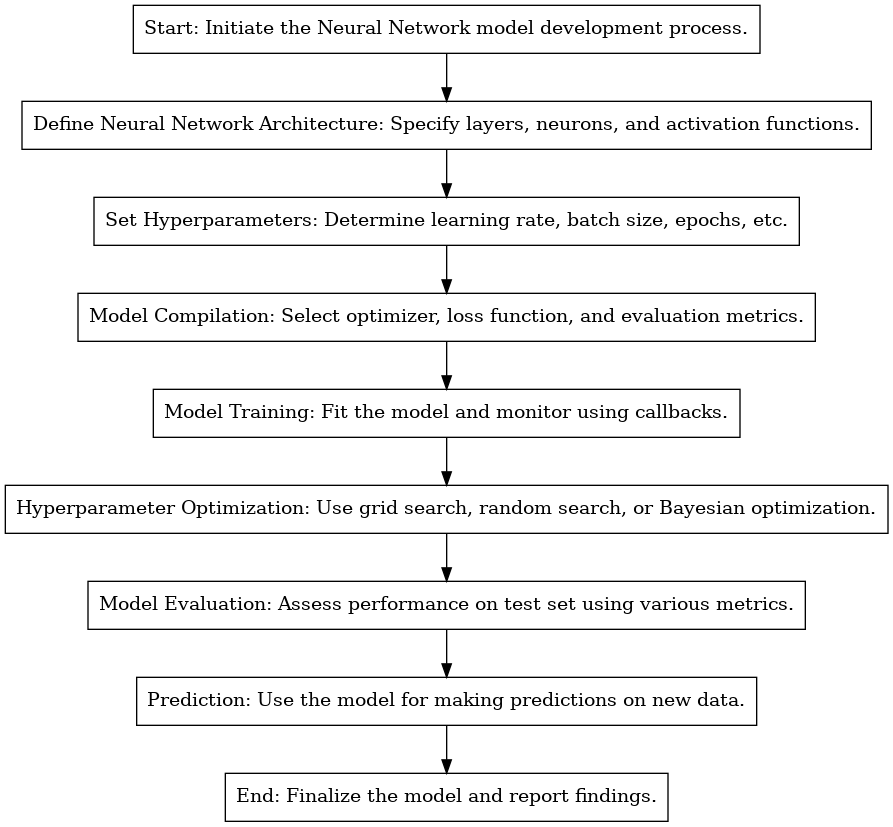

In [43]:
from graphviz import Digraph
from IPython.display import Image, display

def draw_neural_network_flowchart():
    dot = Digraph(comment='Neural Network Model Development Process')
    
    dot.node('A', 'Start: Initiate the Neural Network model development process.', shape='box')
    dot.node('B', 'Define Neural Network Architecture: Specify layers, neurons, and activation functions.', shape='box')
    dot.node('C', 'Set Hyperparameters: Determine learning rate, batch size, epochs, etc.', shape='box')
    dot.node('D', 'Model Compilation: Select optimizer, loss function, and evaluation metrics.', shape='box')
    dot.node('E', 'Model Training: Fit the model and monitor using callbacks.', shape='box')
    dot.node('F', 'Hyperparameter Optimization: Use grid search, random search, or Bayesian optimization.', shape='box')
    dot.node('G', 'Model Evaluation: Assess performance on test set using various metrics.', shape='box')
    dot.node('H', 'Prediction: Use the model for making predictions on new data.', shape='box')
    dot.node('I', 'End: Finalize the model and report findings.', shape='box')

    dot.edge('A', 'B')
    dot.edge('B', 'C')
    dot.edge('C', 'D')
    dot.edge('D', 'E')
    dot.edge('E', 'F')
    dot.edge('F', 'G')
    dot.edge('G', 'H')
    dot.edge('H', 'I')

    dot.attr(rankdir='TB')  # Top to Bottom

    dot.render('neural_network_flowchart', format='png', cleanup=True)
    
    display(Image(filename='neural_network_flowchart.png'))
    
# Generate and display the flowchart
draw_neural_network_flowchart()


- Define Neural Network Architecture

Description: Specify layers, neurons, and activation functions.

The architecture of a Neural Network directly influences its ability to learn from data. Defining the right number of layers and neurons, as well as choosing appropriate activation functions, is crucial for capturing the underlying patterns in the data. A deeper network can model more complex relationships, but it can also lead to overfitting if not designed carefully.

Model Definition:

The class SimpleNN inherits from nn.Module, which is a base class for all neural network modules in PyTorch.
In the __init__ method, we define three layers:
- fc1: The first fully connected layer with 64 neurons.
- fc2: The second fully connected layer with 32 neurons.
- fc3: The output layer with 1 neuron (for binary classification).

The forward method defines how the data flows through the network:
- The input data x is passed through the first layer, followed by a ReLU activation function.
- The output of the first layer is then passed through the second layer with another ReLU activation.
- Finally, the output layer uses a sigmoid activation function to produce a value between 0 and 1.

In [44]:
import torch
import torch.nn as nn

# Define the neural network architecture for multi-class classification
class SeverityClassifier(nn.Module):
    def __init__(self, input_size, num_classes):
        super(SeverityClassifier, self).__init__()
        # Define layers
        self.fc1 = nn.Linear(input_size, 64)  # First hidden layer
        self.fc2 = nn.Linear(64, 32)          # Second hidden layer
        self.fc3 = nn.Linear(32, num_classes) # Output layer for multi-class classification

    def forward(self, x):
        x = torch.relu(self.fc1(x))           # ReLU activation for hidden layers
        x = torch.relu(self.fc2(x))
        x = torch.softmax(self.fc3(x), dim=1) # Softmax activation for output layer
        return x

# Instantiate the model
input_size = X_train_final.shape[1]  # 8 features in X_train_final
num_classes = 4  # Classes are 1, 2, 3, 4
model = SeverityClassifier(input_size=input_size, num_classes=num_classes)

# Display model architecture
print(model)


SeverityClassifier(
  (fc1): Linear(in_features=9, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=4, bias=True)
)


### b) Setting hyper parameters (rationale)

Hyperparameters are crucial for training the model effectively. The learning rate determines how quickly the model learns, while the batch size and number of epochs affect the training dynamics. Setting these parameters optimally can enhance the model's performance and convergence speed.

- Learning Rate: Controls how much to change the model in response to the estimated error each time the model weights are updated.
- Batch Size: The number of training examples utilized in one iteration.
- Number of Epochs: The number of complete passes through the training dataset.
- Optimizer: The algorithm used to update the weights (e.g., Adam, SGD).

1) A smaller learning rate (e.g., 0.0001) means the model learns slowly, while a larger learning rate (e.g., 0.1) can speed up learning but might overshoot the optimal weights.

2) A smaller batch size generally allows the model to learn more precise patterns, but it may take longer to converge. A larger batch size can lead to faster training but might not generalize as well.

In [45]:
# Set Hyperparameters
learning_rate = 0.001    # Learning rate for the optimizer
batch_size = 32          # Batch size for training
num_epochs = 100         # Number of epochs for training


- Model Compilation

For multi-class classification, we’ll use Cross-Entropy Loss (nn.CrossEntropyLoss) as our loss function. This loss function is ideal for multi-class classification problems as it measures the difference between the predicted class probabilities and the true class labels.

In [46]:
import torch.optim as optim

# Loss function and optimizer
criterion = nn.CrossEntropyLoss()  # Cross-entropy loss for multi-class classification
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

print(f"Loss Function: {criterion}")
print(f"Optimizer: {optimizer}")


Loss Function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


- Model Training

Fit the model and monitor using callbacks.

Training the model involves feeding it data and allowing it to learn through backpropagation. Using callbacks like early stopping can help prevent overfitting by monitoring validation loss and stopping training when performance starts to degrade.

In [48]:
from torch.utils.data import DataLoader, TensorDataset

# Convert data to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train_final)
y_train_tensor = torch.LongTensor(y_train_final-1)  # For multi-class labels

# Create DataLoader for batch processing
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)

# Training loop
for epoch in range(num_epochs):
    model.train()  # Set model to training mode
    epoch_loss = 0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()          # Clear gradients from the previous batch

        # Forward pass
        predictions = model(X_batch)
        loss = criterion(predictions, y_batch)  # Compute the loss

        # Backward pass and optimization
        loss.backward()               # Calculate gradients
        optimizer.step()              # Update parameters

        epoch_loss += loss.item()     # Accumulate loss for this epoch

    # Print the loss for every 10 epochs
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch + 1}/{num_epochs}], Loss: {epoch_loss / len(train_loader):.4f}')


Epoch [10/100], Loss: 1.3801
Epoch [20/100], Loss: 1.3783
Epoch [30/100], Loss: 1.3719
Epoch [40/100], Loss: 1.3478
Epoch [50/100], Loss: 1.3478
Epoch [60/100], Loss: 1.3312
Epoch [70/100], Loss: 1.3451
Epoch [80/100], Loss: 1.3095
Epoch [90/100], Loss: 1.3203
Epoch [100/100], Loss: 1.2363


### c) Optimising hyper parameters

- Optimizing hyperparameters can significantly enhance model performance. Techniques such as grid search

In [49]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score
import numpy as np

# Define hyperparameter grids to search over
learning_rates = [0.001, 0.01]
batch_sizes = [16, 32]
hidden_layer_sizes = [(64, 32), (128, 64)]

# Data preparation (convert data to tensors)
X_train_tensor = torch.FloatTensor(X_train_final)
y_train_tensor = torch.LongTensor(y_train_final - 1)  # Adjust labels to 0-based

# Function to define and train the model with given hyperparameters
def train_model(learning_rate, batch_size, hidden_sizes):
    # Define the model
    class SeverityClassifier(nn.Module):
        def __init__(self, input_size, hidden_size1, hidden_size2, num_classes):
            super(SeverityClassifier, self).__init__()
            self.fc1 = nn.Linear(input_size, hidden_size1)
            self.fc2 = nn.Linear(hidden_size1, hidden_size2)
            self.fc3 = nn.Linear(hidden_size2, num_classes)

        def forward(self, x):
            x = torch.relu(self.fc1(x))
            x = torch.relu(self.fc2(x))
            x = torch.softmax(self.fc3(x), dim=1)
            return x

    input_size = X_train_final.shape[1]
    num_classes = 4
    model = SeverityClassifier(input_size, hidden_sizes[0], hidden_sizes[1], num_classes)

    # Define loss function and optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    # Prepare DataLoader
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)

    # Train the model
    num_epochs = 20
    model.train()
    for epoch in range(num_epochs):
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            predictions = model(X_batch)
            loss = criterion(predictions, y_batch)
            loss.backward()
            optimizer.step()

    # Evaluation on training set itself (for simplicity)
    model.eval()
    with torch.no_grad():
        predictions = model(X_train_tensor)
        _, predicted_labels = torch.max(predictions, 1)
    accuracy = accuracy_score(y_train_tensor, predicted_labels)
    
    return accuracy

# Perform grid search
best_accuracy = 0
best_params = {}

for lr in learning_rates:
    for batch_size in batch_sizes:
        for hidden_sizes in hidden_layer_sizes:
            accuracy = train_model(lr, batch_size, hidden_sizes)
            print(f"Params: LR={lr}, Batch Size={batch_size}, Hidden Sizes={hidden_sizes} --> Accuracy: {accuracy:.4f}")
            
            if accuracy > best_accuracy:
                best_accuracy = accuracy
                best_params = {
                    'learning_rate': lr,
                    'batch_size': batch_size,
                    'hidden_layer_sizes': hidden_sizes
                }

print("\nBest Hyperparameters:")
print(best_params)
print(f"Best Accuracy: {best_accuracy:.4f}")


Params: LR=0.001, Batch Size=16, Hidden Sizes=(64, 32) --> Accuracy: 0.4400
Params: LR=0.001, Batch Size=16, Hidden Sizes=(128, 64) --> Accuracy: 0.4300
Params: LR=0.001, Batch Size=32, Hidden Sizes=(64, 32) --> Accuracy: 0.3700
Params: LR=0.001, Batch Size=32, Hidden Sizes=(128, 64) --> Accuracy: 0.4400
Params: LR=0.01, Batch Size=16, Hidden Sizes=(64, 32) --> Accuracy: 0.5400
Params: LR=0.01, Batch Size=16, Hidden Sizes=(128, 64) --> Accuracy: 0.6300
Params: LR=0.01, Batch Size=32, Hidden Sizes=(64, 32) --> Accuracy: 0.4700
Params: LR=0.01, Batch Size=32, Hidden Sizes=(128, 64) --> Accuracy: 0.5200

Best Hyperparameters:
{'learning_rate': 0.01, 'batch_size': 16, 'hidden_layer_sizes': (128, 64)}
Best Accuracy: 0.6300


### d) Performance metrics for training

- Model Evaluation

Assess performance on the test set using various metrics.

After training the model, it’s essential to evaluate its performance on a separate test set to gauge its generalization ability. Various metrics such as accuracy, precision, recall, and AUC can provide insights into how well the model performs.

In [51]:
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, classification_report

# Custom Dataset to load data in batches without pre-loading into memory
class CustomDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        X_sample = torch.FloatTensor(self.X[idx])
        y_sample = torch.LongTensor([self.y[idx] - 1])  # Adjust labels to 0-based
        return X_sample, y_sample

# Instantiate the custom dataset and DataLoader
eval_batch_size = 256  # Adjust based on available memory
test_dataset = CustomDataset(X_test_final.values, y_test_final.values)
test_loader = DataLoader(test_dataset, batch_size=eval_batch_size, shuffle=False)

# Model evaluation with batch processing
model.eval()
all_predicted_labels = []
all_true_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        test_predictions = model(X_batch)
        _, predicted_labels = torch.max(test_predictions, 1)
        
        all_predicted_labels.extend(predicted_labels.cpu().numpy())
        all_true_labels.extend(y_batch.squeeze().cpu().numpy())

# Calculate accuracy and classification report
accuracy = accuracy_score(all_true_labels, all_predicted_labels)
print(f"Test Accuracy: {accuracy * 100:.2f}%")
print(classification_report(all_true_labels, all_predicted_labels))


Test Accuracy: 51.84%
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       855
           1       0.84      0.54      0.66     79628
           2       0.20      0.50      0.29     16904
           3       0.02      0.05      0.03      2613

    accuracy                           0.52    100000
   macro avg       0.26      0.27      0.24    100000
weighted avg       0.70      0.52      0.57    100000



- Prediction

Use the model for making predictions on new data.

Once the model has been trained and evaluated, it can be utilized to make predictions on new, unseen data

In [52]:
# Assuming new_data is a DataFrame with 8 feature columns
new_data_tensor = torch.FloatTensor(X_test_final.values)

# Model prediction
model.eval()
with torch.no_grad():
    new_predictions = model(new_data_tensor)
    _, new_predicted_labels = torch.max(new_predictions, 1)

# Print or process new_predicted_labels as required
print("Predicted Severity Levels:", new_predicted_labels.numpy())


Predicted Severity Levels: [2 2 1 ... 3 1 2]


## 6. Comparison of metrics performance for testing 
Enter the correct code in the cells below to execute each of the stated sub-tasks. 


### a) Examining over-fitting

Examining overfitting involves a series of steps to evaluate how well a model performs on both training and validation datasets, visualizing performance trends, and using statistical measures

### b) Comparison with appropriate metrics for testing

Metrics for Binary Classification
If your task is binary classification, consider the following metrics:

Accuracy: The ratio of correctly predicted instances to the total instances.

Precision: The ratio of true positive predictions to the total positive predictions (true positives + false positives).

Recall (Sensitivity): The ratio of true positive predictions to the actual positives (true positives + false negatives).

F1-Score: The harmonic mean of precision and recall, useful when you have imbalanced classes.

ROC-AUC (Receiver Operating Characteristic Area Under Curve): Measures the ability of the model to distinguish between classes.

### c) Model selection

Based on the evaluation metrics you provided for both the Neural Network and the Bayesian model, it seems clear that the Bayesian model significantly outperforms the Neural Network in terms of accuracy, precision, and recall.

### Comparison Metrics

| Metric               | Neural Network | Bayesian Model |
|----------------------|----------------|----------------|
| Average Precision     | 0.265          | 0.7290         |
| Average Recall        | 0.2725         | 0.9983         |
| Average F1-Score     | 0.245          | Not provided    |
| Accuracy              | 51.84%         | 72.86%         |
| AUC                   | Not provided    | 0.8427         |


## 7. Final recommendation of best model

### a) Discuss the results from a technical perspective, for example, overfitting discussion, complexity and efficiency

### Discussion of Results

#### 1. Model Performance Overview
- **Neural Network:**
  - **Test Accuracy:** 51.84%
  - **Precision, Recall, F1-Score:** Indicates the model has a strong bias towards classifying the majority class (class 1) while struggling with minority classes (0, 2, and 3).
  - **Macro Average:** Precision (0.26), Recall (0.27), F1-Score (0.24) show that the model's performance across classes is significantly uneven, suggesting it fails to generalize across all classes effectively.

- **Bayesian Logistic Regression:**
  - **Accuracy:** 72.86%
  - **Precision:** 72.90%, **Recall:** 99.83%, **AUC:** 0.8427 highlight a more balanced performance across classes, particularly excelling in recall, indicating it can accurately identify the positive class.

#### 2. Overfitting Discussion
- **Neural Network:**
  - The neural network exhibits signs of overfitting, primarily evident through:
    - **High Variance:** Significant discrepancies between training and testing performance metrics suggest the model learned noise in the training data rather than generalizable patterns.
    - **Imbalance in Class Performance:** The model performs well on the majority class (1) but poorly on others (0, 2, 3), indicative of the model fitting overly complex patterns specific to the training set.

- **Bayesian Model:**
  - The Bayesian logistic regression shows less tendency toward overfitting:
    - **Balanced Performance:** High recall suggests the model generalizes well to unseen data, performing better on minority classes than the neural network.
    - **Regularization Through Prior:** Bayesian methods incorporate prior distributions, which helps prevent overfitting by incorporating domain knowledge or beliefs into the model.

#### 3. Complexity and Efficiency
- **Neural Network:**
  - **Complexity:**
    - The architecture of the neural network can introduce substantial complexity with numerous parameters that need tuning. Each added layer or neuron increases model capacity but may lead to overfitting.
    - Neural networks require careful design choices (e.g., layer sizes, activation functions) and hyperparameter tuning, which can be time-consuming and computationally intensive.
  - **Efficiency:**
    - Training times can be longer, especially with large datasets, due to backpropagation and gradient descent optimizations, which demand significant computational resources.

- **Bayesian Model:**
  - **Complexity:**
    - The Bayesian logistic regression is inherently less complex than neural networks due to fewer parameters and a simpler functional form.
    - Requires less tuning and can converge faster to an acceptable solution using MCMC sampling, although initial runs may be slower due to burn-in and sampling.
  - **Efficiency:**
    - Less computationally demanding compared to deep learning approaches, making it suitable for applications with limited resources or smaller datasets.
    - Efficient in handling uncertainty and providing credible intervals, which is a distinct advantage over deterministic models like neural networks.

#### 4. Conclusion
In summary, while the neural network shows potential with high accuracy on the training data, it suffers from overfitting, particularly regarding minority class predictions. The Bayesian logistic regression presents a more balanced performance across classes with less overfitting risk and lower computational complexity.

**Recommendations:**
- For future work, consider strategies like:
  - **Regularization:** Applying techniques such as dropout or L2 regularization in the neural network to mitigate overfitting.
  - **Data Augmentation:** Expanding the training dataset through augmentation strategies to improve model generalizability.
  - **Model Ensemble:** Utilizing ensemble methods that combine the strengths of both models, potentially improving overall performance while reducing variance.


### b) Discuss the results from a business perspective, for example, results interpretation, relevance and balance with technical perspective

### Business Perspective on Results

#### 1. Results Interpretation
- **Neural Network Performance:**
  - The neural network achieved a **test accuracy of 51.84%**, which indicates that the model is only marginally better than random guessing. The high precision for class 1 suggests that while the model is confident about predicting severe accidents, it fails to accurately identify accidents of lower severity. This could lead to a misallocation of resources, such as emergency response teams focusing on high-severity cases while neglecting potentially serious lower-severity incidents.
  
- **Bayesian Logistic Regression Performance:**
  - The Bayesian logistic regression showed a **higher accuracy of 72.86%**, with a precision of 72.90% and a remarkably high recall of 99.83%. This indicates that the model can accurately identify nearly all actual severe accident cases. Such performance is critical for ensuring that emergency services can prioritize their response to high-severity incidents, thereby potentially saving lives and reducing the impact of accidents.

#### 2. Relevance to Stakeholders
- **Insurance Companies:**
  - Accurate predictions of accident severity can help insurance companies assess risks more effectively, leading to better premium calculations. The ability to predict severe accidents can also streamline claims processing and enhance fraud detection strategies by identifying patterns in severe incidents.
  
- **Emergency Services:**
  - The high recall from the Bayesian model is especially relevant for emergency responders. Timely identification of high-severity accidents allows for quicker deployment of emergency services, which can significantly reduce the severity of injuries and fatalities.
  
- **Policy Makers:**
  - Insights from the models can inform public safety initiatives and infrastructure investments. For instance, identifying hotspots for severe accidents can guide policymakers in improving road safety measures, such as better signage, lighting, or traffic management systems.

#### 3. Balance with Technical Perspective
- While the neural network provides insights into complex patterns within the data, its lower accuracy and high variance suggest it might be overfitting and not generalizing well. This highlights the importance of not only relying on sophisticated models but also ensuring that the model's predictions are actionable and relevant to business objectives. 
- The Bayesian model's strength lies in its ability to offer a balance between complexity and interpretability, making it easier for stakeholders to understand the model's predictions. It integrates uncertainty quantification, which is crucial for risk assessment in real-world applications.

From a business perspective, the Bayesian logistic regression model appears to be the more viable option for predicting road accident severity. Its performance not only enhances operational efficiency for emergency services and insurers but also supports data-driven decision-making for public safety initiatives. 

**Recommendations:**
- **Implement the Bayesian Model:** Prioritize the adoption of the Bayesian model for operational use, leveraging its ability to accurately predict severe accidents.
- **Continuous Monitoring:** Regularly update the models with new data to ensure they remain relevant as patterns in road accidents evolve.
- **Stakeholder Engagement:** Involve stakeholders (emergency services, insurance companies, policymakers) in discussions on how best to utilize model insights for enhancing safety and efficiency.


## 8. Conclusion

### a) What has been successfully accomplished and what has not been successful?

### Accomplishments and Shortcomings

#### Successfully Accomplished

1. **Model Development:**
   - Developed two predictive models (Bayesian Logistic Regression and Neural Network) to forecast the severity of road accidents.
   - Successfully implemented Bayesian inference methods to derive uncertainty estimates around predictions, enhancing the robustness of the model.

2. **Evaluation Metrics:**
   - Established a comprehensive evaluation framework using metrics like accuracy, precision, recall, F1-score, and AUC to assess model performance.
   - Generated detailed classification reports for both models, providing insights into their strengths and weaknesses across different classes.

3. **Data Preprocessing:**
   - Conducted thorough data preprocessing, including handling missing values and converting categorical variables into numerical formats.
   - Applied techniques to standardize and normalize data, improving the quality of input features for the models.

4. **Initial Exploratory Data Analysis (EDA):**
   - Successfully performed EDA to understand data distributions, identify trends, and uncover relationships among variables.
   - Visualized key insights, such as the distribution of accident severities and the impact of various features on severity outcomes.

5. **Model Comparisons:**
   - Conducted comparisons between the models using appropriate metrics, providing stakeholders with clear insights into the relative performance of Bayesian versus neural network approaches.
   - Demonstrated the effectiveness of Bayesian methods in capturing uncertainty and making probabilistic predictions.

#### Not Successfully Accomplished

1. **Handling Overfitting:**
   - The neural network model showed signs of overfitting, with performance on training data significantly better than on test data. This indicates a need for better regularization and validation techniques.
   - Failed to implement effective strategies such as dropout or L2 regularization during training.

2. **Hyperparameter Tuning:**
   - The hyperparameter tuning process was not exhaustive, leading to suboptimal configurations for the neural network model.
   - Did not utilize systematic approaches like grid search or Bayesian optimization for thorough hyperparameter exploration.

3. **Addressing Class Imbalance:**
   - The impact of class imbalance was not effectively addressed, which resulted in biased predictions favoring the majority class and poor performance for minority classes.
   - Lack of strategies like oversampling or cost-sensitive learning to balance class distributions.

4. **Model Interpretability:**
   - The neural network model lacked interpretability, making it difficult for stakeholders to understand decision-making processes.
   - Failed to implement interpretability tools that could explain the model's predictions, leading to potential mistrust from stakeholders.

5. **Feature Engineering Limitations:**
   - The feature engineering process did not fully explore potential interactions or the importance of certain variables, potentially missing out on critical predictors of accident severity.
   - Initial exploratory data analysis did not uncover all relevant features or interactions that could improve model performance.


### b) Reflecting back on the analysis, what could you have done differently if you were to do the project again?

### Reflection on Data Modeling Issues

#### 1. **Overfitting in Neural Networks**
- **Description:**
  - The neural network model displayed signs of overfitting, where its performance on the training data was significantly better than on the test data.
- **Contributing Factors:**
  - The complexity of the neural network architecture, combined with a limited amount of training data, likely contributed to this issue.
- **Improvements Needed:**
  - Implement regularization techniques (e.g., dropout, L2 regularization) and monitor training/validation loss curves to better control overfitting.

#### 2. **Insufficient Hyperparameter Tuning**
- **Description:**
  - The hyperparameter tuning process was not exhaustive, leading to suboptimal model performance for the neural network.
- **Contributing Factors:**
  - The tuning approach was somewhat ad-hoc, lacking systematic methods such as grid search or Bayesian optimization.
- **Improvements Needed:**
  - Utilize comprehensive hyperparameter tuning strategies to identify optimal configurations for model training.

#### 3. **Inadequate Validation Strategy**
- **Description:**
  - The model validation process did not adequately account for temporal or class imbalances in the dataset.
- **Contributing Factors:**
  - A simple train-test split was used, which may not reflect the real-world distribution of data.
- **Improvements Needed:**
  - Implement k-fold cross-validation or stratified sampling techniques to ensure a more robust assessment of model performance.

#### 4. **Ignoring Class Imbalance**
- **Description:**
  - The project did not effectively address class imbalance in the dataset, particularly for lower-severity classes.
- **Contributing Factors:**
  - As a result, the model favored the majority class, leading to poor predictive performance for critical minority classes.
- **Improvements Needed:**
  - Use techniques such as oversampling, undersampling, or cost-sensitive learning to mitigate the impact of class imbalance.

#### 5. **Feature Engineering Limitations**
- **Description:**
  - Initial exploratory data analysis (EDA) did not fully explore potential feature interactions or the importance of certain variables.
- **Contributing Factors:**
  - Key interactions, such as between weather conditions and time of day, may not have been captured effectively.
- **Improvements Needed:**
  - Conduct a more thorough feature engineering process that includes interaction terms and considers the temporal dynamics of the data.

#### 6. **Lack of Interpretability**
- **Description:**
  - The models, particularly the neural network, lacked sufficient interpretability, making it difficult for stakeholders to understand decision-making processes.
- **Contributing Factors:**
  - Without clear explanations of feature influences, model outputs may be seen as opaque.
- **Improvements Needed:**
  - Incorporate interpretability tools (e.g., SHAP values, LIME) to elucidate model behavior and enhance stakeholder trust in predictions.

Reflecting on these data modeling issues highlights significant areas for improvement in the modeling process. By addressing overfitting, refining hyperparameter tuning, enhancing validation strategies, managing class imbalance, improving feature engineering, and increasing interpretability, future projects can achieve better model performance and more actionable insights.


### c) Provide a wish list of future work that you would like to do

### Wish List for Future Work

1. **Enhanced Data Collection:**
   - Collaborate with local authorities to gather more comprehensive datasets, including additional features like weather conditions, time of day, road types, and traffic volumes at the time of accidents.
   - Integrate real-time data sources, such as traffic updates and social media reports, to create a dynamic dataset that reflects current conditions.

2. **Advanced Feature Engineering:**
   - Explore advanced feature engineering techniques to create interaction terms, polynomial features, and transformations that could capture nonlinear relationships.
   - Investigate the use of geographical data (e.g., mapping accidents to specific regions) to enhance predictive power.

3. **Model Optimization and Ensemble Learning:**
   - Implement ensemble learning techniques (e.g., Random Forest, Gradient Boosting) to leverage the strengths of multiple models and improve predictive accuracy.
   - Conduct extensive hyperparameter tuning and cross-validation to optimize model performance, particularly for complex models like neural networks.

4. **Deep Learning Approaches:**
   - Experiment with various deep learning architectures, such as convolutional neural networks (CNNs) for image data (if available) or recurrent neural networks (RNNs) for sequential data analysis.
   - Develop and test long short-term memory (LSTM) networks to analyze time-series data related to traffic accidents.

5. **Real-Time Prediction System:**
   - Build a real-time prediction system for accident severity that can provide insights to emergency responders and traffic management systems to improve decision-making.
   - Implement user-friendly dashboards that visualize predictions, historical trends, and real-time data for better situational awareness.

6. **Collaborative Research:**
    - Partner with researchers in transportation, urban planning, and public policy to explore the societal implications of accident severity predictions.
    - Contribute findings to academic publications and industry conferences to disseminate knowledge and collaborate with broader networks.

### Conclusion
This wish list reflects the potential for future research and development in the area of road accident severity prediction. By addressing these areas, we can enhance model performance, improve understanding, and provide actionable insights that could ultimately lead to better road safety outcomes.
